
# FUNWAVE capstone pipeline  
## Full-sequence offshore-to-local time-series prediction at fixed automatic stations

This notebook is designed for the staged capstone workflow:

1. **Stage 1 — simple spectral surrogate**  
   Uses the offshore full sequence, projects it onto the forcing periods already stored in the FUNWAVE files, and learns a fast ridge-regression mapping to the local station signal.

2. **Stage 2 — advanced full-sequence conditional TCN**  
   Uses the **entire** offshore sequence resampled to `dt ≈ 0.6 s`, with **no sliding windows**, so phase lags and propagation remain available to the model.

3. **Stage 3 — physics-informed residual hybrid**  
   Adds an explicit linear-wave-inspired delay/shoaling layer and learns only the residual that linear transfer misses.

A few implementation choices are intentional:

- **No windowing** in Stage 2 or Stage 3.
- One training sample = **one `(run, target station)` full sequence**.
- The notebook is **local-PC and Colab friendly**.
- Station definitions are configurable:
  - manual offshore `x`
  - manual target `x`
  - manual target depths
  - automatic depth-bin stationization

In [ ]:
%pip install -q xarray h5netcdf netCDF4 scipy scikit-learn joblib tqdm psutil


In [1]:

import os
import gc
import io
import json
import math
import time
import random
import zipfile
import hashlib
import warnings
import sys
from pathlib import Path
from functools import lru_cache
from contextlib import contextmanager

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

from scipy.interpolate import interp1d
from scipy.signal import hilbert, welch

from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler

from IPython.display import display
from tqdm.auto import tqdm

try:
    import psutil
except Exception:
    psutil = None

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True

SEED = 20
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

IN_COLAB = "google.colab" in sys.modules
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

if hasattr(torch, "set_float32_matmul_precision"):
    try:
        torch.set_float32_matmul_precision("high")
    except Exception:
        pass

if DEVICE == "cpu":
    try:
        torch.set_num_threads(max(1, min(8, os.cpu_count() or 1)))
    except Exception:
        pass

print("IN_COLAB:", IN_COLAB)
print("DEVICE:", DEVICE)
print("CPU count:", os.cpu_count())
if psutil is not None:
    vm = psutil.virtual_memory()
    print("RAM total (GB):", round(vm.total / (1024 ** 3), 2))
    print("RAM available (GB):", round(vm.available / (1024 ** 3), 2))


IN_COLAB: False
DEVICE: cpu
CPU count: 16
RAM total (GB): 63.7
RAM available (GB): 15.35


C:\Users\adami\anaconda3\envs\Ali_USD\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## User configuration

This notebook is set up to run either on:
- a **local PC**
- or **Colab + Google Drive**

The most important sections to edit are:

1. **data root**
2. **data root** (the station logic is already fixed by default)
3. **optional station overrides**
4. **profile size** (`smoke_test`, `capstone_default`, `capstone_large`)

Default behavior:
- recursively finds `.nc` files under `DATA_ROOT`
- extracts `.nc` files from `.zip` archives if needed
- defines the **offshore station**: first dynamically valid, sufficiently wet point after bathymetry starts changing
- defines the landward cutoff as the last dynamically valid, sufficiently wet point
- places **10 target stations** between those two limits
- trims spin-up using `t_prop + margin`
- resamples to `dt = 0.6 s`
- builds one sample per `(run, station)` pair


In [2]:

# =========================
# Configuration
# =========================

PROFILE = "capstone_default"   # choose from: "smoke_test", "capstone_default", "capstone_large"

# General execution toggles
RUN_STAGE1 = True
RUN_STAGE2 = True
RUN_STAGE3 = True
SAVE_MODEL_BUNDLES = True

# Dataset size control
USER_MAX_RUNS_TOTAL = 5000          # None = use all discovered files
USER_DATA_ACCESS_MODE = "auto"      # "auto", "ram", "lazy"
REBUILD_METADATA = False
REBUILD_PREPROCESSING = False

# Paths
USER_DATA_ROOT = None
USER_ARTIFACT_ROOT = None

USE_COLAB_DRIVE = IN_COLAB
COLAB_DATA_ROOT = Path("/content/drive/MyDrive/FUNWAVE_capstone_data")

LOCAL_DATA_ROOT_CANDIDATES = [
    Path("./"),
    Path("./data"),
    Path("/mnt/data"),
]

# Station definition
# Default offshore rule = the same one used in your shared notebook:
# first dynamically valid, sufficiently wet point after the bathymetry starts changing.
OFFSHORE_SELECTOR_MODE = "profile_dynamic_valid"   # "profile_dynamic_valid", "manual_x", "manual_depth"
OFFSHORE_X = None
OFFSHORE_DEPTH_TARGET = None

# Default target-station rule:
# choose 10 stations shoreward of the offshore input, up to the last dynamically valid/wet point.
# They are placed on quantiles of cumulative travel time (tau), then snapped to valid grid points.
TARGET_SELECTOR_MODE = "auto_valid_tau_quantiles"  # "auto_valid_tau_quantiles", "auto_valid_x_quantiles", "manual_x", "manual_depths"
TARGET_X_LIST = []
TARGET_DEPTH_LIST = []
TARGET_AUTO_N = 10

# Split policy
SPLIT_GROUP_MODE = "run"   # "run" or "profile"
VAL_FRAC = 0.15
TEST_FRAC = 0.15

# Feature schemas
# strict_core       -> Hs, Tp, local depth
# with_geometry     -> strict_core + dx_to_offshore + local_slope
# with_physics_aux  -> with_geometry + tau_path + shoaling_gain_path
STAGE1_FEATURE_SCHEMA = "strict_core"
STAGE2_FEATURE_SCHEMA = "with_geometry"
STAGE3_FEATURE_SCHEMA = "with_physics_aux"

# Time-channel schemas
# raw_only           -> offshore only
# core_derived       -> offshore, envelope, time-derivative
# physics_augmented  -> core_derived + delay trace + physics baseline
STAGE2_CHANNEL_SCHEMA = "core_derived"
STAGE3_CHANNEL_SCHEMA = "physics_augmented"

PROFILE_SETTINGS = {
    "smoke_test": {
        "max_runs_total": 32,
        "target_dt": 0.6,
        "spinup_margin_seconds": 40.0,
        "offshore_buffer_after_source_m": 20.0,
        "offshore_min_depth": 1.0,
        "offshore_min_wet_fraction": 0.95,
        "target_min_wet_fraction": 0.50,
        "dynamic_min_std_frac": 0.05,
        "dynamic_min_std_abs": 1e-3,
        "bathy_change_tol": 1e-6,
        "bathy_change_min_consecutive": 3,
        "min_target_spacing_m": 15.0,
        "min_depth_feature": 0.05,
        "gravity": 9.81,
        "metadata_n_jobs": 2,
        "preprocess_n_jobs": 2,
        "loader_num_workers": 0,
        "stage1_alpha_grid": [1e-3, 1e-2, 1e-1, 1.0, 10.0],
        "stage2_batch_size": 2 if DEVICE == "cuda" else 1,
        "stage2_hidden_channels": 16,
        "stage2_dilations": [1, 2, 4, 8, 16],
        "stage2_kernel_size": 5,
        "stage2_dropout": 0.05,
        "stage2_epochs": 4,
        "stage2_patience": 2,
        "stage2_learning_rate": 1e-3,
        "stage2_weight_decay": 1e-4,
        "stage3_batch_size": 2 if DEVICE == "cuda" else 1,
        "stage3_hidden_channels": 16,
        "stage3_dilations": [1, 2, 4, 8, 16],
        "stage3_kernel_size": 5,
        "stage3_dropout": 0.05,
        "stage3_epochs": 4,
        "stage3_patience": 2,
        "stage3_learning_rate": 1e-3,
        "stage3_weight_decay": 1e-4,
        "corr_loss_weight": 0.12,
        "ig_loss_weight": 0.06,
        "ss_loss_weight": 0.08,
        "physics_reg_weight": 0.05,
    },
    "capstone_default": {
        "max_runs_total": 1000,
        "target_dt": 0.6,
        "spinup_margin_seconds": 40.0,
        "offshore_buffer_after_source_m": 20.0,
        "offshore_min_depth": 1.0,
        "offshore_min_wet_fraction": 0.95,
        "target_min_wet_fraction": 0.50,
        "dynamic_min_std_frac": 0.05,
        "dynamic_min_std_abs": 1e-3,
        "bathy_change_tol": 1e-6,
        "bathy_change_min_consecutive": 3,
        "min_target_spacing_m": 15.0,
        "min_depth_feature": 0.05,
        "gravity": 9.81,
        "metadata_n_jobs": max(1, min(8, os.cpu_count() or 1)),
        "preprocess_n_jobs": max(1, min(8, os.cpu_count() or 1)),
        "loader_num_workers": 0,
        "stage1_alpha_grid": [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0],
        "stage2_batch_size": 8 if DEVICE == "cuda" else 2,
        "stage2_hidden_channels": 64 if DEVICE == "cuda" else 32,
        "stage2_dilations": [1, 2, 4, 8, 16, 32, 64, 128],
        "stage2_kernel_size": 5,
        "stage2_dropout": 0.06,
        "stage2_epochs": 20,
        "stage2_patience": 5,
        "stage2_learning_rate": 8e-4,
        "stage2_weight_decay": 1e-4,
        "stage3_batch_size": 8 if DEVICE == "cuda" else 2,
        "stage3_hidden_channels": 64 if DEVICE == "cuda" else 32,
        "stage3_dilations": [1, 2, 4, 8, 16, 32, 64, 128],
        "stage3_kernel_size": 5,
        "stage3_dropout": 0.06,
        "stage3_epochs": 25,
        "stage3_patience": 6,
        "stage3_learning_rate": 7e-4,
        "stage3_weight_decay": 1e-4,
        "corr_loss_weight": 0.12,
        "ig_loss_weight": 0.06,
        "ss_loss_weight": 0.08,
        "physics_reg_weight": 0.05,
    },
    "capstone_large": {
        "max_runs_total": None,
        "target_dt": 0.6,
        "spinup_margin_seconds": 40.0,
        "offshore_buffer_after_source_m": 20.0,
        "offshore_min_depth": 1.0,
        "offshore_min_wet_fraction": 0.95,
        "target_min_wet_fraction": 0.50,
        "dynamic_min_std_frac": 0.05,
        "dynamic_min_std_abs": 1e-3,
        "bathy_change_tol": 1e-6,
        "bathy_change_min_consecutive": 3,
        "min_target_spacing_m": 15.0,
        "min_depth_feature": 0.05,
        "gravity": 9.81,
        "metadata_n_jobs": max(1, min(12, os.cpu_count() or 1)),
        "preprocess_n_jobs": max(1, min(12, os.cpu_count() or 1)),
        "loader_num_workers": 0,
        "stage1_alpha_grid": [1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0],
        "stage2_batch_size": 12 if DEVICE == "cuda" else 2,
        "stage2_hidden_channels": 80 if DEVICE == "cuda" else 32,
        "stage2_dilations": [1, 2, 4, 8, 16, 32, 64, 128, 256],
        "stage2_kernel_size": 5,
        "stage2_dropout": 0.06,
        "stage2_epochs": 30,
        "stage2_patience": 7,
        "stage2_learning_rate": 6e-4,
        "stage2_weight_decay": 1e-4,
        "stage3_batch_size": 12 if DEVICE == "cuda" else 2,
        "stage3_hidden_channels": 80 if DEVICE == "cuda" else 32,
        "stage3_dilations": [1, 2, 4, 8, 16, 32, 64, 128, 256],
        "stage3_kernel_size": 5,
        "stage3_dropout": 0.06,
        "stage3_epochs": 35,
        "stage3_patience": 8,
        "stage3_learning_rate": 6e-4,
        "stage3_weight_decay": 1e-4,
        "corr_loss_weight": 0.12,
        "ig_loss_weight": 0.06,
        "ss_loss_weight": 0.08,
        "physics_reg_weight": 0.05,
    },
}

def choose_local_data_root():
    if USER_DATA_ROOT is not None:
        return Path(USER_DATA_ROOT)

    for cand in LOCAL_DATA_ROOT_CANDIDATES:
        if cand.exists():
            if list(cand.rglob("*.nc")) or list(cand.rglob("*.zip")):
                return cand

    for cand in LOCAL_DATA_ROOT_CANDIDATES:
        if cand.exists():
            return cand

    return Path("./")

if IN_COLAB and USE_COLAB_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    DATA_ROOT = Path(USER_DATA_ROOT) if USER_DATA_ROOT is not None else COLAB_DATA_ROOT
    ARTIFACT_ROOT = Path(USER_ARTIFACT_ROOT) if USER_ARTIFACT_ROOT is not None else Path("/content/funwave_capstone_station_artifacts")
else:
    DATA_ROOT = choose_local_data_root()
    ARTIFACT_ROOT = Path(USER_ARTIFACT_ROOT) if USER_ARTIFACT_ROOT is not None else Path("./funwave_capstone_station_artifacts")

EXTRACT_ROOT = ARTIFACT_ROOT / "extracted_nc"
CACHE_ROOT = ARTIFACT_ROOT / "cache"
RUN_CACHE_DIR = CACHE_ROOT / "processed_station_runs"
FIGURE_ROOT = ARTIFACT_ROOT / "figures"
TABLE_ROOT = ARTIFACT_ROOT / "tables"
MODEL_ROOT = ARTIFACT_ROOT / "models"

for p in [ARTIFACT_ROOT, EXTRACT_ROOT, CACHE_ROOT, RUN_CACHE_DIR, FIGURE_ROOT, TABLE_ROOT, MODEL_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

cfg = dict(PROFILE_SETTINGS[PROFILE])

if USER_MAX_RUNS_TOTAL is not None:
    cfg["max_runs_total"] = USER_MAX_RUNS_TOTAL

cfg.update({
    "profile": PROFILE,
    "data_root": str(DATA_ROOT),
    "artifact_root": str(ARTIFACT_ROOT),
    "rebuild_metadata": bool(REBUILD_METADATA),
    "rebuild_preprocessing": bool(REBUILD_PREPROCESSING),
    "data_access_mode": USER_DATA_ACCESS_MODE,
    "offshore_selector_mode": OFFSHORE_SELECTOR_MODE,
    "offshore_x": OFFSHORE_X,
    "offshore_depth_target": OFFSHORE_DEPTH_TARGET,
    "target_selector_mode": TARGET_SELECTOR_MODE,
    "target_x_list": list(TARGET_X_LIST),
    "target_depth_list": list(TARGET_DEPTH_LIST),
    "target_auto_n": int(TARGET_AUTO_N),
    "stage1_feature_schema": STAGE1_FEATURE_SCHEMA,
    "stage2_feature_schema": STAGE2_FEATURE_SCHEMA,
    "stage2_channel_schema": STAGE2_CHANNEL_SCHEMA,
    "stage3_feature_schema": STAGE3_FEATURE_SCHEMA,
    "stage3_channel_schema": STAGE3_CHANNEL_SCHEMA,
    "split_group_mode": SPLIT_GROUP_MODE,
    "val_frac": float(VAL_FRAC),
    "test_frac": float(TEST_FRAC),
})

cfg["split_group_col"] = "run_id" if cfg["split_group_mode"] == "run" else "profile_hash"

print("DATA_ROOT:", DATA_ROOT)
print("ARTIFACT_ROOT:", ARTIFACT_ROOT)
print(json.dumps(cfg, indent=2))


DATA_ROOT: .
ARTIFACT_ROOT: funwave_capstone_station_artifacts
{
  "max_runs_total": 5000,
  "target_dt": 0.6,
  "spinup_margin_seconds": 40.0,
  "offshore_buffer_after_source_m": 20.0,
  "offshore_min_depth": 1.0,
  "offshore_min_wet_fraction": 0.95,
  "target_min_wet_fraction": 0.5,
  "dynamic_min_std_frac": 0.05,
  "dynamic_min_std_abs": 0.001,
  "bathy_change_tol": 1e-06,
  "bathy_change_min_consecutive": 3,
  "min_target_spacing_m": 15.0,
  "min_depth_feature": 0.05,
  "gravity": 9.81,
  "metadata_n_jobs": 8,
  "preprocess_n_jobs": 8,
  "loader_num_workers": 0,
  "stage1_alpha_grid": [
    0.0001,
    0.001,
    0.01,
    0.1,
    1.0,
    10.0
  ],
  "stage2_batch_size": 2,
  "stage2_hidden_channels": 32,
  "stage2_dilations": [
    1,
    2,
    4,
    8,
    16,
    32,
    64,
    128
  ],
  "stage2_kernel_size": 5,
  "stage2_dropout": 0.06,
  "stage2_epochs": 20,
  "stage2_patience": 5,
  "stage2_learning_rate": 0.0008,
  "stage2_weight_decay": 0.0001,
  "stage3_batch_size": 


## File discovery and lightweight metadata

This section:
- finds `.nc` files recursively
- extracts `.nc` files from `.zip` archives if needed
- builds a lightweight metadata table
- optionally truncates to `USER_MAX_RUNS_TOTAL`


In [3]:

# =========================
# Discovery + metadata
# =========================

def open_dataset_safe(path):
    try:
        return xr.open_dataset(path, engine="h5netcdf")
    except Exception:
        return xr.open_dataset(path)

@contextmanager
def tqdm_joblib(tqdm_object):
    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old_callback = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old_callback
        tqdm_object.close()

def iter_nc_file_candidates(data_root, extract_root):
    data_root = Path(data_root)
    extract_root = Path(extract_root)
    extract_root.mkdir(parents=True, exist_ok=True)

    seen = set()

    for path in sorted(data_root.rglob("*.nc")):
        rp = str(path.resolve())
        if rp not in seen:
            seen.add(rp)
            yield path

    for zpath in sorted(data_root.rglob("*.zip")):
        try:
            with zipfile.ZipFile(zpath, "r") as zf:
                for member in zf.namelist():
                    if not member.lower().endswith(".nc"):
                        continue
                    target = extract_root / zpath.stem / member
                    target.parent.mkdir(parents=True, exist_ok=True)
                    if not target.exists():
                        with zf.open(member) as src, open(target, "wb") as dst:
                            dst.write(src.read())
                    rp = str(target.resolve())
                    if rp not in seen:
                        seen.add(rp)
                        yield target
        except Exception as e:
            print(f"Warning: could not inspect zip file {zpath}: {e}")

def discover_nc_files(data_root, extract_root):
    nc_files = list(iter_nc_file_candidates(data_root, extract_root))
    if len(nc_files) == 0:
        raise FileNotFoundError(f"No .nc files were found under {data_root}")
    return nc_files

def detect_var_name(ds, preferred_names):
    for name in preferred_names:
        if name in ds.variables:
            return name
    lowmap = {k.lower(): k for k in ds.variables}
    for name in preferred_names:
        if name.lower() in lowmap:
            return lowmap[name.lower()]
    raise KeyError(f"None of {preferred_names} found. Available: {list(ds.variables)}")

def detect_time_name_for_var(ds, var_name):
    da = ds[var_name]
    for dim in da.dims:
        if "t" in dim.lower():
            return dim
    for cand in ["t_FW", "time", "t"]:
        if cand in ds.variables or cand in ds.coords:
            return cand
    raise KeyError(f"Could not detect time dimension for {var_name}")

def infer_run_id(ds, path):
    for k in ["TITLE", "title", "run_id", "RunID"]:
        if k in ds.attrs:
            return str(ds.attrs[k])
    return Path(path).stem

def estimate_peak_period_from_trace(t, y):
    t = np.asarray(t, dtype=np.float64).ravel()
    y = np.asarray(y, dtype=np.float64).ravel()
    if len(t) < 16 or np.std(y) < 1e-8:
        return np.nan
    dt = np.median(np.diff(t))
    if not np.isfinite(dt) or dt <= 0:
        return np.nan
    y0 = y - np.mean(y)
    freqs = np.fft.rfftfreq(len(y0), d=dt)
    spec = np.abs(np.fft.rfft(y0)) ** 2
    valid = (freqs > 0.02) & (freqs < 1.0)
    if not np.any(valid):
        return np.nan
    fpk = freqs[valid][np.argmax(spec[valid])]
    return float(1.0 / max(fpk, 1e-6))

def compute_profile_hash(x, z, max_points=256):
    x = np.asarray(x).ravel()
    z = np.asarray(z).ravel()
    if len(x) > max_points:
        idx = np.linspace(0, len(x) - 1, max_points).round().astype(int)
        x = x[idx]
        z = z[idx]
    h = hashlib.md5()
    h.update(np.asarray(x, dtype=np.float32).tobytes())
    h.update(np.asarray(z, dtype=np.float32).tobytes())
    return h.hexdigest()[:12]

def read_light_metadata(path):
    path = Path(path)
    try:
        with open_dataset_safe(path) as ds:
            eta_name = detect_var_name(ds, ["eta", "ETA"])
            x_name = detect_var_name(ds, ["X", "x"])
            z_name = detect_var_name(ds, ["Z", "z", "depth"])
            t_name = detect_time_name_for_var(ds, eta_name)

            x = np.asarray(ds[x_name].values, dtype=np.float32)
            z = np.asarray(ds[z_name].values, dtype=np.float32)
            t = np.asarray(ds[t_name].values, dtype=np.float64)

            hs = ds.attrs.get("Hs", np.nan)
            tp = ds.attrs.get("PeakPeriod", ds.attrs.get("Tp", np.nan))

            out = {
                "ok": True,
                "source_path": str(path),
                "run_id": infer_run_id(ds, path),
                "profile_hash": compute_profile_hash(x, z),
                "n_x": int(len(x)),
                "n_t": int(len(t)),
                "x_min": float(np.nanmin(x)),
                "x_max": float(np.nanmax(x)),
                "z_min": float(np.nanmin(z)),
                "z_max": float(np.nanmax(z)),
                "t_min": float(np.nanmin(t)),
                "t_max": float(np.nanmax(t)),
                "Hs": float(hs) if np.isfinite(hs) else np.nan,
                "Tp": float(tp) if np.isfinite(tp) else np.nan,
                "t_prop": float(ds.attrs.get("t_prop", np.nan)),
                "Xc_WK": float(ds.attrs.get("Xc_WK", np.nan)),
                "has_period_var": bool("period" in ds.variables),
                "period_len": int(ds["period"].size) if "period" in ds.variables else 0,
                "file_size_mb": round(path.stat().st_size / (1024 ** 2), 3),
            }

            if not np.isfinite(out["Tp"]) and eta_name in ds.variables:
                eta = np.asarray(ds[eta_name].values, dtype=np.float32)
                if eta.ndim == 2 and eta.shape[1] > 0:
                    out["Tp"] = estimate_peak_period_from_trace(t, eta[:, 0])

            return out
    except Exception as e:
        return {
            "ok": False,
            "source_path": str(path),
            "error": repr(e),
        }

def metadata_signature(paths):
    joined = "||".join(sorted(str(Path(p).resolve()) for p in paths))
    return hashlib.md5(joined.encode("utf-8")).hexdigest()[:16]

def load_or_build_metadata(nc_files, cache_path, rebuild=False, n_jobs=1):
    cache_path = Path(cache_path)
    sig = metadata_signature(nc_files)

    if cache_path.exists() and not rebuild:
        payload = joblib.load(cache_path)
        if payload.get("signature") == sig:
            return payload["metadata_df"]

    with tqdm_joblib(tqdm(total=len(nc_files), desc="Read metadata")):
        rows = joblib.Parallel(n_jobs=n_jobs)(
            joblib.delayed(read_light_metadata)(p) for p in nc_files
        )

    metadata_df = pd.DataFrame(rows)
    joblib.dump({"signature": sig, "metadata_df": metadata_df}, cache_path)
    return metadata_df

all_nc_files = discover_nc_files(DATA_ROOT, EXTRACT_ROOT)
print("Discovered .nc files:", len(all_nc_files))

metadata_cache_path = CACHE_ROOT / "metadata_cache.joblib"
metadata_df = load_or_build_metadata(
    all_nc_files,
    metadata_cache_path,
    rebuild=cfg["rebuild_metadata"],
    n_jobs=cfg["metadata_n_jobs"],
)

metadata_df.to_csv(TABLE_ROOT / "metadata_table.csv", index=False)

valid_meta_df = metadata_df[metadata_df["ok"] == True].copy()
print("Valid files:", len(valid_meta_df))
display(valid_meta_df.head())

selected_meta_df = valid_meta_df.copy()
if cfg["max_runs_total"] is not None and len(selected_meta_df) > int(cfg["max_runs_total"]):
    rng = np.random.default_rng(SEED)
    keep_idx = rng.permutation(len(selected_meta_df))[: int(cfg["max_runs_total"])]
    selected_meta_df = selected_meta_df.iloc[np.sort(keep_idx)].copy()

selected_nc_files = [Path(p) for p in selected_meta_df["source_path"].tolist()]
selected_meta_df.to_csv(TABLE_ROOT / "selected_metadata_table.csv", index=False)

print("Selected runs for this notebook:", len(selected_nc_files))
display(selected_meta_df[["run_id", "profile_hash", "n_x", "n_t", "Hs", "Tp", "t_prop", "Xc_WK"]].head())


Discovered .nc files: 33098
Valid files: 33098


,ok,source_path,run_id,profile_hash,n_x,n_t,x_min,x_max,z_min,z_max,t_min,t_max,Hs,Tp,t_prop,Xc_WK,has_period_var,period_len,file_size_mb
0,True,funwave_capstone_artifacts_v8_field\extracted_...,input_00001,05939d552a98,873,7802,0.0,1044.122559,-1.077637,9.227356,0.0,1170.19702,2.929343,10.000000,146.285380,293.360119,True,62,11.160
1,True,funwave_capstone_artifacts_v8_field\extracted_...,input_00002,c07f18c9a420,867,8431,0.0,1130.247437,-3.587646,7.892395,0.0,1264.52673,1.073329,10.810811,158.076220,319.758237,True,62,10.781
2,True,funwave_capstone_artifacts_v8_field\extracted_...,input_00004,b0791040e0c7,725,7753,0.0,1274.453125,-2.677979,8.685974,0.0,1162.85425,2.203202,14.285714,145.369688,431.272119,True,62,8.862
3,True,funwave_capstone_artifacts_v8_field\extracted_...,input_00005,d1cde9916358,882,8137,0.0,1054.899048,-1.579224,8.163757,0.0,1220.39758,0.792421,10.000000,152.566058,293.360119,True,62,10.433
4,True,funwave_capstone_artifacts_v8_field\extracted_...,input_00006,4545c47a2d57,923,8645,0.0,1103.991943,-3.056396,7.761597,0.0,1296.62146,0.411135,10.000000,162.081554,293.360119,True,62,10.790


Selected runs for this notebook: 5000


,run_id,profile_hash,n_x,n_t,Hs,Tp,t_prop,Xc_WK
2,input_00004,b0791040e0c7,725,7753,2.203202,14.285714,145.369688,431.272119
6,input_00008,b3ccdf914076,1199,9079,0.502168,6.896552,170.231493,189.620445
14,input_00017,bff4c22e7d4a,860,8120,0.630439,10.810811,152.252203,319.758237
43,input_00070,c346d1bd4c66,979,8769,1.286663,9.302325,164.404592,270.470089
48,input_00077,c26162619f82,969,8773,0.597108,9.302325,164.483296,270.470089



## Point-station preprocessing

Each processed run cache stores:

- a single **offshore reference time series**
- the resampled time grid `t`
- run-level features (`Hs`, `Tp`, offshore station info)
- a list of **target stations**
- for each station:
  - full local target sequence
  - valid-time mask
  - local depth
  - station distance
  - path-integrated travel time
  - linear-shoaling proxy
  - a precomputed physics baseline
  - optional spectral coefficients for Stage 1


In [4]:

# =========================
# Preprocessing helpers
# =========================

FEATURE_SCHEMAS = {
    "strict_core": ["Hs", "Tp", "depth_target"],
    "with_geometry": ["Hs", "Tp", "depth_target", "dx_to_offshore", "local_slope"],
    "with_physics_aux": ["Hs", "Tp", "depth_target", "dx_to_offshore", "local_slope", "tau_path", "shoaling_gain_path"],
}

TIME_CHANNEL_SCHEMAS = {
    "raw_only": ["offshore"],
    "core_derived": ["offshore", "offshore_env", "offshore_dt"],
    "physics_augmented": ["offshore", "offshore_env", "offshore_dt", "delay_trace", "physics_baseline"],
}

def clean_and_sort_time(t, *arrays):
    t = np.asarray(t, dtype=np.float64).ravel()
    keep = np.isfinite(t)
    order = np.argsort(t[keep])
    t2 = t[keep][order]

    out = []
    for arr in arrays:
        a = np.asarray(arr)
        a = a[keep]
        a = a[order]
        out.append(a)

    uniq, idx = np.unique(t2, return_index=True)
    out = [a[idx] for a in out]
    return uniq, out

def effective_dt_from_time(t):
    dt = np.diff(np.asarray(t, dtype=np.float64))
    dt = dt[np.isfinite(dt) & (dt > 0)]
    if len(dt) == 0:
        raise ValueError("Could not infer a positive dt from the time vector.")
    return float(np.median(dt))

def resample_to_uniform_time(t, arr, target_dt, kind="linear"):
    t = np.asarray(t, dtype=np.float64).ravel()
    arr = np.asarray(arr)

    t, [arr] = clean_and_sort_time(t, arr)
    t_new = np.arange(t[0], t[-1] + 0.5 * target_dt, target_dt, dtype=np.float64)

    squeeze = False
    if arr.ndim == 1:
        arr = arr[:, None]
        squeeze = True

    out = np.empty((len(t_new), arr.shape[1]), dtype=np.float32)

    for j in range(arr.shape[1]):
        col = np.asarray(arr[:, j], dtype=np.float64)
        finite = np.isfinite(col)
        if finite.sum() < 2:
            out[:, j] = 0.0
            continue

        f = interp1d(
            t[finite],
            col[finite],
            kind=kind,
            bounds_error=False,
            fill_value=(col[finite][0], col[finite][-1]),
            assume_sorted=True,
        )
        out[:, j] = f(t_new).astype(np.float32)

    if squeeze:
        out = out[:, 0]

    return t_new, out

def clean_and_sort_x(x, *arrays):
    x = np.asarray(x, dtype=np.float64).ravel()
    keep = np.isfinite(x)
    order = np.argsort(x[keep])
    x2 = x[keep][order]

    out = []
    for arr in arrays:
        a = np.asarray(arr)
        if a.ndim == 1:
            a2 = a[keep][order]
        elif a.shape[-1] == len(x):
            a2 = np.take(a[..., keep], order, axis=-1)
        else:
            raise ValueError(f"Array shape {a.shape} is incompatible with x length {len(x)}")
        out.append(a2)

    uniq, idx = np.unique(x2, return_index=True)
    out2 = []
    for a in out:
        if a.ndim == 1:
            out2.append(a[idx])
        else:
            out2.append(np.take(a, idx, axis=-1))

    return uniq.astype(np.float32), out2

def smooth_slope(x, z):
    x = np.asarray(x, dtype=np.float64)
    z = np.asarray(z, dtype=np.float64)
    if len(x) < 3:
        return np.zeros_like(z, dtype=np.float32)
    return np.gradient(z, x).astype(np.float32)

def to_positive_water_depth(z):
    z = np.asarray(z, dtype=np.float64)
    cand1 = np.maximum(z, 0.0)
    cand2 = np.maximum(-z, 0.0)

    n = max(4, len(z) // 4)
    score1 = np.nanmedian(cand1[:n])
    score2 = np.nanmedian(cand2[:n])

    if score1 >= score2:
        return cand1.astype(np.float32), "z_positive_is_depth"
    return cand2.astype(np.float32), "z_negative_is_depth"

def find_profile_start_index(z, tol=1e-6, min_consecutive=3):
    z = np.asarray(z, dtype=np.float64)
    if len(z) < min_consecutive + 1:
        return 0

    dz = np.abs(np.diff(z))
    changed = dz > tol

    for i in range(len(changed) - min_consecutive + 1):
        if np.all(changed[i : i + min_consecutive]):
            return i + 1
    return 0

def detect_dynamic_valid_interval(
    x,
    z,
    eta,
    mask,
    min_wet_fraction=0.50,
    min_std_frac=0.05,
    min_std_abs=1e-3,
    bathy_change_tol=1e-6,
    bathy_change_min_consecutive=3,
):
    """
    Matches the offshore/shoreline logic:
    - profile starts when bathymetry begins changing
    - offshore station = first wet + dynamically active point after that
    - landward cutoff = last wet + dynamically active point
    """
    x = np.asarray(x, dtype=np.float32)
    z = np.asarray(z, dtype=np.float32)
    eta = np.asarray(eta, dtype=np.float32)
    mask = np.asarray(mask, dtype=np.float32)

    std_x = np.nanstd(eta, axis=0)
    wet_frac_x = np.mean(mask > 0.5, axis=0)

    profile_start_idx = find_profile_start_index(
        z,
        tol=bathy_change_tol,
        min_consecutive=bathy_change_min_consecutive,
    )

    positive_std = std_x[np.isfinite(std_x) & (std_x > 0)]
    ref_std = float(np.nanpercentile(positive_std, 95)) if len(positive_std) else 0.0
    std_thresh = max(float(min_std_abs), float(min_std_frac) * ref_std)

    valid = np.where(
        (np.arange(len(x)) >= profile_start_idx) &
        (wet_frac_x >= float(min_wet_fraction)) &
        (std_x >= std_thresh)
    )[0]

    if len(valid) == 0:
        valid = np.where(
            (np.arange(len(x)) >= profile_start_idx) &
            (std_x >= float(min_std_abs))
        )[0]

    if len(valid) == 0:
        raise ValueError("Could not identify a valid wet/dynamic offshore-to-shoreline interval.")

    offshore_idx = int(max(profile_start_idx, valid[0]))
    shoreline_idx = int(valid[-1])

    if shoreline_idx <= offshore_idx:
        raise ValueError("Detected shoreline index is not landward of offshore index.")

    return {
        "offshore_idx": int(offshore_idx),
        "shoreline_idx": int(shoreline_idx),
        "profile_start_idx": int(profile_start_idx),
        "std_x": std_x.astype(np.float32),
        "wet_frac_x": wet_frac_x.astype(np.float32),
        "std_thresh": float(std_thresh),
        "valid_idx": valid.astype(np.int64),
    }

def cumulative_tau_from_offshore(x, depth, offshore_idx, tp, gravity=9.81):
    x = np.asarray(x, dtype=np.float64)
    depth = np.maximum(np.asarray(depth, dtype=np.float64), 0.05)

    if offshore_idx >= len(x) - 1:
        return np.zeros(len(x), dtype=np.float32)

    seg = slice(int(offshore_idx), len(x))
    x_seg = x[seg]
    h_seg = depth[seg]
    cg_seg = np.maximum(group_velocity_from_depth_and_period(h_seg, tp, gravity=gravity), 1e-4)

    dx = np.diff(x_seg, prepend=x_seg[0])
    tau_seg = np.cumsum(dx / cg_seg)
    tau_seg -= tau_seg[0]

    tau = np.zeros(len(x), dtype=np.float32)
    tau[seg] = tau_seg.astype(np.float32)
    return tau

def choose_quantile_indices(valid_idx, metric, n_select, x, min_dx_m=15.0):
    valid_idx = np.asarray(valid_idx, dtype=np.int64)
    metric = np.asarray(metric, dtype=np.float64)
    x = np.asarray(x, dtype=np.float64)

    if len(valid_idx) == 0:
        return []

    n_select = int(max(1, n_select))
    n_select = min(n_select, len(valid_idx))

    # Use quantiles from (0, 1], so the offshore input itself is excluded
    q = np.linspace(0.0, 1.0, n_select + 1)[1:]
    targets = np.quantile(metric, q)

    chosen = []
    used = set()

    for target in targets:
        order = np.argsort(np.abs(metric - target))
        picked = None
        for k in order:
            idx = int(valid_idx[k])
            if idx in used:
                continue
            picked = idx
            break
        if picked is not None:
            chosen.append(picked)
            used.add(picked)

    chosen = sorted(set(chosen), key=lambda i: x[int(i)])

    out = []
    for idx in chosen:
        idx = int(idx)
        if len(out) > 0 and (x[idx] - x[out[-1]]) < float(min_dx_m):
            continue
        out.append(idx)

    if len(out) == 0:
        out = [int(valid_idx[min(len(valid_idx) - 1, n_select - 1)])]

    return out

def select_target_indices(
    x,
    depth,
    wet_frac_x,
    std_x,
    std_thresh,
    offshore_idx,
    shoreline_idx,
    tp,
    mode="auto_valid_tau_quantiles",
    manual_x_list=None,
    manual_depths=None,
    auto_n=10,
    min_wet=0.50,
    min_dx_m=15.0,
    gravity=9.81,
):
    """
    Default "best" target-station rule:
    - use only the same dynamically valid + wet interval used to define offshore/shoreline
    - exclude the offshore input location
    - place <= auto_n stations up to the last valid eta point
    - by default use cumulative-travel-time quantiles, which spreads stations in phase-propagation space
    """
    x = np.asarray(x, dtype=np.float64)
    depth = np.asarray(depth, dtype=np.float64)
    wet_frac_x = np.asarray(wet_frac_x, dtype=np.float64)
    std_x = np.asarray(std_x, dtype=np.float64)

    valid = np.where(
        (np.arange(len(x)) > int(offshore_idx)) &
        (np.arange(len(x)) <= int(shoreline_idx)) &
        (wet_frac_x >= float(min_wet)) &
        (std_x >= float(std_thresh))
    )[0]

    if len(valid) == 0:
        valid = np.where(
            (np.arange(len(x)) > int(offshore_idx)) &
            (np.arange(len(x)) <= int(shoreline_idx)) &
            (wet_frac_x >= float(min_wet))
        )[0]

    if len(valid) == 0:
        return []

    if mode == "manual_x":
        chosen = []
        for xt in (manual_x_list or []):
            idx = valid[np.argmin(np.abs(x[valid] - float(xt)))]
            chosen.append(int(idx))
        return choose_quantile_indices(np.asarray(sorted(set(chosen))), x[np.asarray(sorted(set(chosen)))], len(set(chosen)), x, min_dx_m=min_dx_m)

    if mode == "manual_depths":
        chosen = []
        for dtarget in (manual_depths or []):
            idx = valid[np.argmin(np.abs(depth[valid] - float(dtarget)))]
            chosen.append(int(idx))
        return choose_quantile_indices(np.asarray(sorted(set(chosen))), x[np.asarray(sorted(set(chosen)))], len(set(chosen)), x, min_dx_m=min_dx_m)

    if mode == "auto_valid_x_quantiles":
        metric = x[valid]
        return choose_quantile_indices(valid, metric, auto_n, x, min_dx_m=min_dx_m)

    if mode == "auto_valid_tau_quantiles":
        tau_all = cumulative_tau_from_offshore(x, depth, offshore_idx, tp, gravity=gravity)
        metric = tau_all[valid]
        # fallback if tau degenerates
        if np.nanmax(metric) <= 0:
            metric = x[valid]
        return choose_quantile_indices(valid, metric, auto_n, x, min_dx_m=min_dx_m)

    raise ValueError(f"Unknown target selector mode: {mode}")

def wavenumber_from_omega_depth(omega, depth, gravity=9.81, n_iter=40):
    omega = np.asarray(omega, dtype=np.float64)
    depth = np.asarray(depth, dtype=np.float64)
    k = np.maximum((omega ** 2) / gravity, 1e-8)

    for _ in range(n_iter):
        kh = k * depth
        tanh_kh = np.tanh(kh)
        f = gravity * k * tanh_kh - omega ** 2
        df = gravity * (tanh_kh + k * depth * (1.0 - tanh_kh ** 2))
        k = np.maximum(k - f / np.maximum(df, 1e-12), 1e-8)

    return k

def group_velocity_from_depth_and_period(depth, peak_period, gravity=9.81):
    depth = np.asarray(depth, dtype=np.float64)
    tp = float(max(peak_period, 1e-6))
    omega = 2.0 * np.pi / tp
    k = wavenumber_from_omega_depth(omega, np.maximum(depth, 1e-6), gravity=gravity)
    c = omega / np.maximum(k, 1e-8)
    kh = k * depth
    n = 0.5 * (1.0 + (2.0 * kh) / np.sinh(np.maximum(2.0 * kh, 1e-8)))
    cg = n * c
    return cg

def shift_trace(trace, dt, shift_seconds):
    trace = np.asarray(trace, dtype=np.float32).reshape(-1)
    n = len(trace)
    if n == 0:
        return trace.copy()

    positions = np.arange(n, dtype=np.float32) - float(shift_seconds) / max(float(dt), 1e-6)
    j0 = np.floor(positions).astype(int)
    alpha = positions - j0
    j1 = j0 + 1

    j0c = np.clip(j0, 0, n - 1)
    j1c = np.clip(j1, 0, n - 1)

    out = (1.0 - alpha) * trace[j0c] + alpha * trace[j1c]
    out = np.where(positions < 0.0, trace[0], out)
    out = np.where(positions > float(n - 1), trace[-1], out)
    return out.astype(np.float32)

def integrate_tau_and_gain(x, depth, offshore_idx, target_idx, tp, gravity=9.81):
    if target_idx <= offshore_idx:
        return 0.0, 1.0

    seg = slice(offshore_idx, target_idx + 1)
    x_seg = np.asarray(x[seg], dtype=np.float64)
    h_seg = np.maximum(np.asarray(depth[seg], dtype=np.float64), 0.05)

    cg_seg = group_velocity_from_depth_and_period(h_seg, tp, gravity=gravity)
    cg_seg = np.maximum(cg_seg, 1e-4)

    dx = np.diff(x_seg)
    cg_mid = 0.5 * (cg_seg[:-1] + cg_seg[1:])

    tau = np.sum(dx / np.maximum(cg_mid, 1e-4))
    gain = np.sqrt(np.maximum(cg_seg[0], 1e-6) / np.maximum(cg_seg[-1], 1e-6))
    return float(tau), float(gain)

def project_onto_period_basis(t, y, periods, ridge=1e-6):
    t = np.asarray(t, dtype=np.float64).ravel()
    y = np.asarray(y, dtype=np.float64).ravel()
    periods = np.asarray(periods, dtype=np.float64).ravel()

    tt = t - t[0]
    omega = 2.0 * np.pi / periods
    C = np.cos(np.outer(tt, omega))
    S = np.sin(np.outer(tt, omega))
    A = np.concatenate([C, S], axis=1)

    ATA = A.T @ A
    ATy = A.T @ y
    coef = np.linalg.solve(ATA + ridge * np.eye(ATA.shape[0]), ATy)

    n = len(periods)
    return coef[:n].astype(np.float32), coef[n:].astype(np.float32)

def reconstruct_from_period_basis(t, periods, cos_coef, sin_coef):
    t = np.asarray(t, dtype=np.float64).ravel()
    periods = np.asarray(periods, dtype=np.float64).ravel()
    tt = t - t[0]
    omega = 2.0 * np.pi / periods
    y = (
        np.cos(np.outer(tt, omega)) @ np.asarray(cos_coef, dtype=np.float64) +
        np.sin(np.outer(tt, omega)) @ np.asarray(sin_coef, dtype=np.float64)
    )
    return y.astype(np.float32)

def cache_key_for_run_stationized(path, cfg_subset):
    payload = {
        "path": str(Path(path).resolve()),
        "target_dt": cfg_subset["target_dt"],
        "spinup_margin_seconds": cfg_subset["spinup_margin_seconds"],
        "offshore_selector_mode": cfg_subset["offshore_selector_mode"],
        "offshore_x": cfg_subset["offshore_x"],
        "offshore_depth_target": cfg_subset["offshore_depth_target"],
        "offshore_buffer_after_source_m": cfg_subset["offshore_buffer_after_source_m"],
        "offshore_min_depth": cfg_subset["offshore_min_depth"],
        "offshore_min_wet_fraction": cfg_subset["offshore_min_wet_fraction"],
        "target_selector_mode": cfg_subset["target_selector_mode"],
        "target_x_list": list(cfg_subset["target_x_list"]),
        "target_depth_list": list(cfg_subset["target_depth_list"]),
        "target_auto_n": cfg_subset["target_auto_n"],
        "target_min_wet_fraction": cfg_subset["target_min_wet_fraction"],
        "min_target_spacing_m": cfg_subset["min_target_spacing_m"],
    }
    s = json.dumps(payload, sort_keys=True)
    return hashlib.md5(s.encode("utf-8")).hexdigest()[:16]

def cache_path_for_run_stationized(path, cfg_subset):
    path = Path(path)
    key = cache_key_for_run_stationized(path, cfg_subset)
    return RUN_CACHE_DIR / f"{path.stem}__{key}.joblib"

def preprocess_run_stationized(path, cfg):
    path = Path(path)
    cp = cache_path_for_run_stationized(path, cfg)

    if cp.exists() and not cfg["rebuild_preprocessing"]:
        return joblib.load(cp, mmap_mode="r")

    with open_dataset_safe(path) as ds:
        eta_name = detect_var_name(ds, ["eta", "ETA"])
        bathy_name = detect_var_name(ds, ["Z", "z", "depth"])
        x_name = detect_var_name(ds, ["X", "x"])
        t_name = detect_time_name_for_var(ds, eta_name)

        eta = np.asarray(ds[eta_name].values, dtype=np.float32)
        x = np.asarray(ds[x_name].values, dtype=np.float32)
        z = np.asarray(ds[bathy_name].values, dtype=np.float32)
        t = np.asarray(ds[t_name].values, dtype=np.float64)

        if "mask" in ds:
            mask = np.asarray(ds["mask"].values, dtype=np.float32)
        else:
            mask = np.ones_like(eta, dtype=np.float32)

        nubrk = np.asarray(ds["nubrk"].values, dtype=np.float32) if "nubrk" in ds else None
        periods_raw = np.asarray(ds["period"].values, dtype=np.float32) if "period" in ds else None
        forcing_amp_raw = np.asarray(ds["amp"].values, dtype=np.float32) if "amp" in ds else None
        forcing_phase_raw = np.asarray(ds["phase"].values, dtype=np.float32) if "phase" in ds else None

        x, arrs = clean_and_sort_x(x, z, eta, mask, *([] if nubrk is None else [nubrk]))
        if nubrk is None:
            z, eta, mask = arrs
        else:
            z, eta, mask, nubrk = arrs

        t, arrs = clean_and_sort_time(t, eta, mask, *([] if nubrk is None else [nubrk]))
        if nubrk is None:
            eta, mask = arrs
        else:
            eta, mask, nubrk = arrs

        if eta.ndim != 2:
            raise ValueError(f"Expected eta to be 2D [time, x], got {eta.shape}")

        if mask.ndim == 1:
            mask = np.repeat(mask[None, :], eta.shape[0], axis=0).astype(np.float32)

        depth, depth_convention = to_positive_water_depth(z)

        interval = detect_dynamic_valid_interval(
            x=x,
            z=z,
            eta=eta,
            mask=mask,
            min_wet_fraction=cfg["target_min_wet_fraction"],
            min_std_frac=cfg["dynamic_min_std_frac"],
            min_std_abs=cfg["dynamic_min_std_abs"],
            bathy_change_tol=cfg["bathy_change_tol"],
            bathy_change_min_consecutive=cfg["bathy_change_min_consecutive"],
        )

        wet_frac_x = interval["wet_frac_x"]
        std_x = interval["std_x"]
        std_thresh = interval["std_thresh"]
        profile_start_idx = interval["profile_start_idx"]

        offshore_idx = int(interval["offshore_idx"])
        if cfg["offshore_selector_mode"] == "manual_x" and cfg["offshore_x"] is not None:
            offshore_idx = int(np.argmin(np.abs(x - float(cfg["offshore_x"]))))
        elif cfg["offshore_selector_mode"] == "manual_depth" and cfg["offshore_depth_target"] is not None:
            offshore_idx = int(np.argmin(np.abs(depth - float(cfg["offshore_depth_target"]))))
        elif cfg["offshore_selector_mode"] not in {"profile_dynamic_valid", "manual_x", "manual_depth"}:
            raise ValueError(f"Unknown offshore selector mode: {cfg['offshore_selector_mode']}")

        shoreline_idx = int(interval["shoreline_idx"])
        if shoreline_idx <= offshore_idx:
            raise ValueError("Shoreline index is not landward of the offshore index.")

        hs = ds.attrs.get("Hs", np.nan)
        tp = ds.attrs.get("PeakPeriod", ds.attrs.get("Tp", np.nan))

        if not np.isfinite(tp):
            tp = estimate_peak_period_from_trace(t, eta[:, offshore_idx])

        if not np.isfinite(hs):
            hs = 4.0 * float(np.nanstd(eta[:, offshore_idx]))

        target_indices = select_target_indices(
            x=x,
            depth=depth,
            wet_frac_x=wet_frac_x,
            std_x=std_x,
            std_thresh=std_thresh,
            offshore_idx=offshore_idx,
            shoreline_idx=shoreline_idx,
            tp=tp,
            mode=cfg["target_selector_mode"],
            manual_x_list=cfg["target_x_list"],
            manual_depths=cfg["target_depth_list"],
            auto_n=cfg["target_auto_n"],
            min_wet=cfg["target_min_wet_fraction"],
            min_dx_m=cfg["min_target_spacing_m"],
            gravity=cfg["gravity"],
        )

        if len(target_indices) == 0:
            raise ValueError("No target stations were selected after preprocessing.")

        trim_start = float(ds.attrs.get("t_prop", 0.0)) + float(cfg["spinup_margin_seconds"])
        if not np.isfinite(trim_start):
            trim_start = float(cfg["spinup_margin_seconds"])

        keep_t = t >= trim_start
        if keep_t.sum() < 64:
            keep_t = np.ones_like(t, dtype=bool)

        t_trim = t[keep_t]
        eta_trim = eta[keep_t]
        mask_trim = mask[keep_t]
        nubrk_trim = nubrk[keep_t] if nubrk is not None else None

        t_ds, eta_ds = resample_to_uniform_time(
            t_trim,
            eta_trim,
            cfg["target_dt"],
            kind="linear",
        )
        _, mask_ds = resample_to_uniform_time(
            t_trim,
            mask_trim,
            cfg["target_dt"],
            kind="nearest",
        )
        mask_ds = (mask_ds >= 0.5).astype(np.float32)

        if nubrk_trim is not None:
            _, nubrk_ds = resample_to_uniform_time(
                t_trim,
                nubrk_trim,
                cfg["target_dt"],
                kind="linear",
            )
        else:
            nubrk_ds = None

        offshore = eta_ds[:, offshore_idx].astype(np.float32)
        offshore_env = np.abs(hilbert(offshore.astype(np.float64))).astype(np.float32)
        offshore_dt = np.gradient(offshore.astype(np.float64), float(cfg["target_dt"])).astype(np.float32)

        hs = ds.attrs.get("Hs", np.nan)
        tp = ds.attrs.get("PeakPeriod", ds.attrs.get("Tp", np.nan))

        if not np.isfinite(tp):
            tp = estimate_peak_period_from_trace(t_ds, offshore)

        if not np.isfinite(hs):
            hs = 4.0 * float(np.nanstd(offshore))

        hs = float(hs)
        tp = float(tp)

        slope = smooth_slope(x, depth)

        periods_used = None
        offshore_coeff_cos = None
        offshore_coeff_sin = None

        if periods_raw is not None:
            freq_raw = 1.0 / np.maximum(periods_raw.astype(np.float64), 1e-6)
            nyq = 1.0 / (2.0 * float(cfg["target_dt"]))
            keep_p = freq_raw < nyq
            periods_used = periods_raw[keep_p].astype(np.float32)

            if len(periods_used) > 0:
                offshore_coeff_cos, offshore_coeff_sin = project_onto_period_basis(
                    t_ds,
                    offshore,
                    periods_used,
                )

        stations = []
        for rank, idx in enumerate(target_indices):
            target = eta_ds[:, idx].astype(np.float32)
            target_mask = mask_ds[:, idx].astype(np.float32)

            tau_path, shoaling_gain = integrate_tau_and_gain(
                x=x,
                depth=depth,
                offshore_idx=offshore_idx,
                target_idx=idx,
                tp=tp,
                gravity=cfg["gravity"],
            )

            delay_trace = shift_trace(offshore, float(cfg["target_dt"]), tau_path)
            physics_baseline = (shoaling_gain * delay_trace).astype(np.float32)

            target_coeff_cos = None
            target_coeff_sin = None
            if periods_used is not None and len(periods_used) > 0:
                target_coeff_cos, target_coeff_sin = project_onto_period_basis(
                    t_ds,
                    target,
                    periods_used,
                )

            station_label = f"h{float(depth[idx]):.2f}m_x{float(x[idx]):.1f}"

            stations.append({
                "station_id": f"station_{rank:02d}",
                "station_rank": int(rank),
                "station_label": station_label,
                "x_target": float(x[idx]),
                "depth_target": float(max(depth[idx], cfg["min_depth_feature"])),
                "local_slope": float(slope[idx]),
                "dx_to_offshore": float(x[idx] - x[offshore_idx]),
                "tau_path": float(tau_path),
                "shoaling_gain_path": float(shoaling_gain),
                "target": target.astype(np.float32),
                "target_mask": target_mask.astype(np.float32),
                "wet_fraction": float(np.mean(target_mask > 0.5)),
                "target_std": float(np.nanstd(target)),
                "mean_nubrk": float(np.nanmean(nubrk_ds[:, idx])) if nubrk_ds is not None else np.nan,
                "delay_trace": delay_trace.astype(np.float32),
                "physics_baseline": physics_baseline.astype(np.float32),
                "target_coeff_cos": None if target_coeff_cos is None else target_coeff_cos.astype(np.float32),
                "target_coeff_sin": None if target_coeff_sin is None else target_coeff_sin.astype(np.float32),
            })

        item = {
            "run_id": infer_run_id(ds, path),
            "profile_hash": compute_profile_hash(x, z),
            "source_path": str(path),
            "cache_path": str(cp),
            "t": t_ds.astype(np.float64),
            "x": x.astype(np.float32),
            "z": z.astype(np.float32),
            "depth": depth.astype(np.float32),
            "depth_convention": depth_convention,
            "offshore_idx": int(offshore_idx),
            "offshore_x": float(x[offshore_idx]),
            "offshore_depth": float(max(depth[offshore_idx], cfg["min_depth_feature"])),
            "shoreline_idx": int(shoreline_idx),
            "shoreline_x": float(x[shoreline_idx]),
            "profile_start_idx": int(profile_start_idx),
            "dynamic_std_threshold": float(std_thresh),
            "offshore": offshore.astype(np.float32),
            "offshore_env": offshore_env.astype(np.float32),
            "offshore_dt": offshore_dt.astype(np.float32),
            "Hs": hs,
            "Tp": tp,
            "dt": float(cfg["target_dt"]),
            "trim_start": float(trim_start),
            "periods_used": None if periods_used is None else periods_used.astype(np.float32),
            "offshore_coeff_cos": None if offshore_coeff_cos is None else offshore_coeff_cos.astype(np.float32),
            "offshore_coeff_sin": None if offshore_coeff_sin is None else offshore_coeff_sin.astype(np.float32),
            "forcing_periods_raw": None if periods_raw is None else periods_raw.astype(np.float32),
            "forcing_amp_raw": None if forcing_amp_raw is None else forcing_amp_raw.astype(np.float32),
            "forcing_phase_raw": None if forcing_phase_raw is None else forcing_phase_raw.astype(np.float32),
            "source_x_wk": float(ds.attrs.get("Xc_WK", np.nan)) if np.isfinite(ds.attrs.get("Xc_WK", np.nan)) else np.nan,
            "stations": stations,
        }

    joblib.dump(item, cp, compress=0)
    return joblib.load(cp, mmap_mode="r")

def summarize_run_item(item):
    return {
        "run_id": item["run_id"],
        "profile_hash": item["profile_hash"],
        "cache_path": item["cache_path"],
        "source_path": item["source_path"],
        "n_stations": len(item["stations"]),
        "nt": len(item["t"]),
        "dt": float(item["dt"]),
        "Hs": float(item["Hs"]),
        "Tp": float(item["Tp"]),
        "offshore_x": float(item["offshore_x"]),
        "offshore_depth": float(item["offshore_depth"]),
        "trim_start": float(item["trim_start"]),
    }

def station_rows_from_item(item):
    rows = []
    for s in item["stations"]:
        rows.append({
            "cache_path": item["cache_path"],
            "run_id": item["run_id"],
            "profile_hash": item["profile_hash"],
            "station_id": s["station_id"],
            "station_rank": s["station_rank"],
            "station_label": s["station_label"],
            "n_samples": int(len(item["t"])),
            "duration_s": float(item["t"][-1] - item["t"][0]) if len(item["t"]) > 1 else 0.0,
            "depth_target": float(s["depth_target"]),
            "x_target": float(s["x_target"]),
            "dx_to_offshore": float(s["dx_to_offshore"]),
            "tau_path": float(s["tau_path"]),
            "shoaling_gain_path": float(s["shoaling_gain_path"]),
            "local_slope": float(s["local_slope"]),
            "wet_fraction": float(s["wet_fraction"]),
            "target_std": float(s["target_std"]),
            "Hs": float(item["Hs"]),
            "Tp": float(item["Tp"]),
        })
    return rows

def preprocess_path_to_cache_summary(path, cfg):
    path = Path(path)
    try:
        item = preprocess_run_stationized(path, cfg)
        return {
            "ok": True,
            "cache_path": item["cache_path"],
            "run_summary": summarize_run_item(item),
            "station_rows": station_rows_from_item(item),
        }
    except Exception as e:
        return {
            "ok": False,
            "source_path": str(path),
            "error": repr(e),
        }

def preprocess_paths(paths, cfg, n_jobs=1):
    with tqdm_joblib(tqdm(total=len(paths), desc="Preprocess runs")):
        results = joblib.Parallel(n_jobs=n_jobs)(
            joblib.delayed(preprocess_path_to_cache_summary)(p, cfg) for p in paths
        )

    ok_results = [r for r in results if r["ok"]]
    bad_results = [r for r in results if not r["ok"]]

    run_rows = []
    station_rows = []
    cache_paths = []

    for r in ok_results:
        cache_paths.append(r["cache_path"])
        run_rows.append(r["run_summary"])
        station_rows.extend(r["station_rows"])

    run_df = pd.DataFrame(run_rows)
    sample_manifest_df = pd.DataFrame(station_rows)
    failed_df = pd.DataFrame(bad_results)

    return cache_paths, run_df, sample_manifest_df, failed_df

processed_run_cache_paths, run_df, sample_manifest_df, failed_df = preprocess_paths(
    selected_nc_files,
    cfg,
    n_jobs=cfg["preprocess_n_jobs"],
)

run_df.to_csv(TABLE_ROOT / "processed_run_table.csv", index=False)
sample_manifest_df.to_csv(TABLE_ROOT / "station_sample_manifest.csv", index=False)
failed_df.to_csv(TABLE_ROOT / "preprocess_failures.csv", index=False)

print("Processed run caches:", len(processed_run_cache_paths))
print("Total station samples:", len(sample_manifest_df))
print("Failed runs:", len(failed_df))

display(run_df.head())
display(sample_manifest_df.head())


Preprocess runs: 100%|██████████| 5000/5000 [17:08<00:00,  4.86it/s]


Processed run caches: 5000
Total station samples: 50000
Failed runs: 0


,run_id,profile_hash,cache_path,source_path,n_stations,nt,dt,Hs,Tp,offshore_x,offshore_depth,trim_start
0,input_00004,b0791040e0c7,funwave_capstone_station_artifacts\cache\proce...,funwave_capstone_artifacts_v8_field\extracted_...,10,1630,0.6,2.203202,14.285714,556.252991,8.673889,185.369688
1,input_00008,b3ccdf914076,funwave_capstone_station_artifacts\cache\proce...,funwave_capstone_artifacts_v8_field\extracted_...,10,1920,0.6,0.502168,6.896552,244.571671,7.610901,210.231493
2,input_00017,bff4c22e7d4a,funwave_capstone_station_artifacts\cache\proce...,funwave_capstone_artifacts_v8_field\extracted_...,10,1710,0.6,0.630439,10.810811,412.422882,8.840576,192.252203
3,input_00070,c346d1bd4c66,funwave_capstone_station_artifacts\cache\proce...,funwave_capstone_artifacts_v8_field\extracted_...,10,1852,0.6,1.286663,9.302325,348.851227,7.918152,204.404592
4,input_00077,c26162619f82,funwave_capstone_station_artifacts\cache\proce...,funwave_capstone_artifacts_v8_field\extracted_...,10,1853,0.6,0.597108,9.302325,348.851227,7.658203,204.483296


,cache_path,run_id,profile_hash,station_id,station_rank,station_label,n_samples,duration_s,depth_target,x_target,dx_to_offshore,tau_path,shoaling_gain_path,local_slope,wet_fraction,target_std,Hs,Tp
0,funwave_capstone_station_artifacts\cache\proce...,input_00004,b0791040e0c7,station_00,0,h8.21m_x626.7,1630,977.4,8.211182,626.664795,70.411804,8.410170,1.011452,-0.008478,1.0,0.525835,2.203202,14.285714
1,funwave_capstone_station_artifacts\cache\proce...,input_00004,b0791040e0c7,station_01,1,h7.67m_x697.1,1630,977.4,7.665833,697.076538,140.823547,17.040581,1.026174,-0.006813,1.0,0.524094,2.203202,14.285714
2,funwave_capstone_station_artifacts\cache\proce...,input_00004,b0791040e0c7,station_02,2,h7.04m_x765.7,1630,977.4,7.041382,765.728027,209.475037,25.726865,1.044936,-0.007559,1.0,0.512062,2.203202,14.285714
3,funwave_capstone_station_artifacts\cache\proce...,input_00004,b0791040e0c7,station_03,3,h6.30m_x836.1,1630,977.4,6.304382,836.139832,279.886841,35.016761,1.070273,-0.015221,1.0,0.508944,2.203202,14.285714
4,funwave_capstone_station_artifacts\cache\proce...,input_00004,b0791040e0c7,station_04,4,h5.57m_x904.8,1630,977.4,5.568420,904.791321,348.538330,44.558004,1.099962,-0.010645,1.0,0.496985,2.203202,14.285714


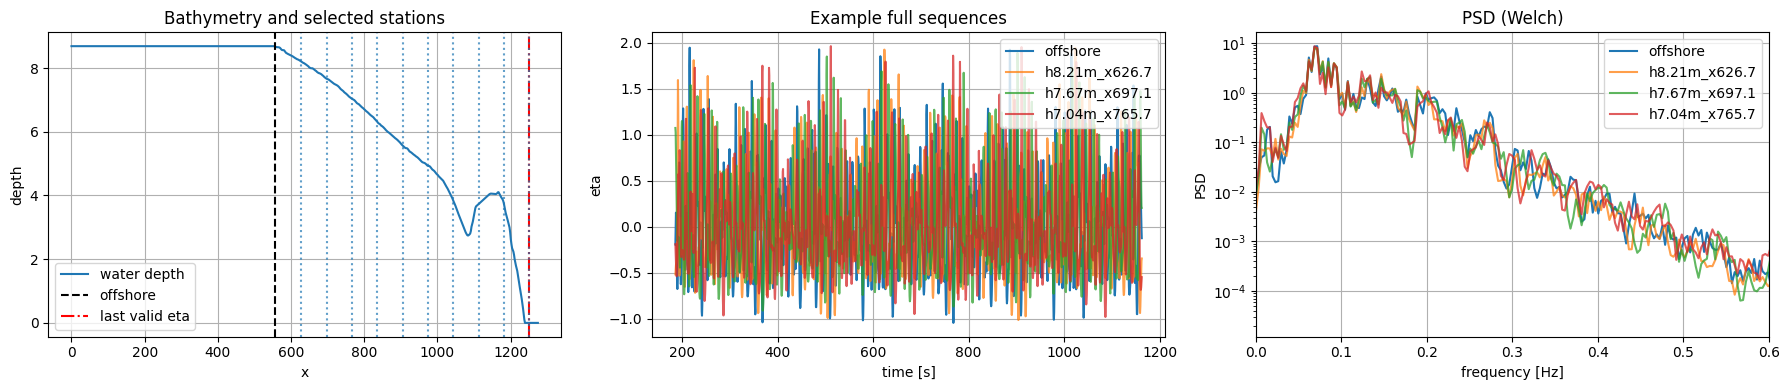

Example run: input_00004
Offshore x: 556.2529907226562
Offshore depth: 8.67388916015625
Stations:


,station_id,station_label,x_target,depth_target,dx_to_offshore,tau_path,shoaling_gain_path,wet_fraction
0,station_00,h8.21m_x626.7,626.664795,8.211182,70.411804,8.410170,1.011452,1.00000
1,station_01,h7.67m_x697.1,697.076538,7.665833,140.823547,17.040581,1.026174,1.00000
2,station_02,h7.04m_x765.7,765.728027,7.041382,209.475037,25.726865,1.044936,1.00000
3,station_03,h6.30m_x836.1,836.139832,6.304382,279.886841,35.016761,1.070273,1.00000
4,station_04,h5.57m_x904.8,904.791321,5.568420,348.538330,44.558004,1.099962,1.00000
5,station_05,h4.93m_x973.4,973.442810,4.931519,417.189819,54.640816,1.130283,1.00000
6,station_06,h3.82m_x1043.9,1043.854614,3.820374,487.601624,65.750646,1.198134,1.00000
7,station_07,h3.73m_x1112.5,1112.505981,3.729065,556.252991,78.358781,1.204855,1.00000
8,station_08,h3.67m_x1182.9,1182.917847,3.665039,626.664856,90.119159,1.209699,1.00000
9,station_09,h0.00m_x1251.6,1251.569336,0.050000,695.316345,124.481214,3.476835,0.57546


In [5]:

# Quick preprocessing sanity plots for one example run
if len(processed_run_cache_paths) == 0:
    raise RuntimeError("No processed runs are available.")

example_item = joblib.load(processed_run_cache_paths[0], mmap_mode="r")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].plot(example_item["x"], example_item["depth"], label="water depth")
axes[0].axvline(example_item["offshore_x"], color="k", linestyle="--", label="offshore")
axes[0].axvline(example_item["shoreline_x"], color="r", linestyle="-.", label="last valid eta")
for s in example_item["stations"]:
    axes[0].axvline(s["x_target"], linestyle=":", alpha=0.7)
axes[0].set_title("Bathymetry and selected stations")
axes[0].set_xlabel("x")
axes[0].set_ylabel("depth")
axes[0].legend(loc="best")

axes[1].plot(example_item["t"], example_item["offshore"], label="offshore")
for s in example_item["stations"][:3]:
    axes[1].plot(example_item["t"], s["target"], alpha=0.75, label=s["station_label"])
axes[1].set_title("Example full sequences")
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("eta")
axes[1].legend(loc="best")

f_off, p_off = welch(example_item["offshore"], fs=1.0 / example_item["dt"], nperseg=min(512, len(example_item["offshore"])))
axes[2].semilogy(f_off, p_off, label="offshore")
for s in example_item["stations"][:3]:
    f_st, p_st = welch(s["target"], fs=1.0 / example_item["dt"], nperseg=min(512, len(s["target"])))
    axes[2].semilogy(f_st, p_st, alpha=0.75, label=s["station_label"])
axes[2].set_title("PSD (Welch)")
axes[2].set_xlabel("frequency [Hz]")
axes[2].set_ylabel("PSD")
axes[2].set_xlim(0.0, 0.6)
axes[2].legend(loc="best")

plt.tight_layout()
plt.savefig(FIGURE_ROOT / "example_stationization.png", dpi=150, bbox_inches="tight")
plt.show()

print("Example run:", example_item["run_id"])
print("Offshore x:", example_item["offshore_x"])
print("Offshore depth:", example_item["offshore_depth"])
print("Stations:")
display(pd.DataFrame([
    {
        "station_id": s["station_id"],
        "station_label": s["station_label"],
        "x_target": s["x_target"],
        "depth_target": s["depth_target"],
        "dx_to_offshore": s["dx_to_offshore"],
        "tau_path": s["tau_path"],
        "shoaling_gain_path": s["shoaling_gain_path"],
        "wet_fraction": s["wet_fraction"],
    }
    for s in example_item["stations"]
]))



## Train / validation / test split  
## RAM-preferred or lazy loading  
## Stage-specific scalers  
## Full-sequence dataset and collate


In [6]:

# =========================
# Split + loading + scalers + datasets
# =========================

def bytes_to_gb(n_bytes):
    return float(n_bytes) / (1024 ** 3)

def available_ram_bytes():
    if psutil is None:
        return None
    try:
        return int(psutil.virtual_memory().available)
    except Exception:
        return None

def choose_data_access_mode(cache_paths, requested_mode="auto", safety_fraction=0.45):
    requested_mode = str(requested_mode).lower()
    if requested_mode in {"ram", "lazy"}:
        return requested_mode

    total_cache_bytes = sum(Path(p).stat().st_size for p in cache_paths if Path(p).exists())
    avail = available_ram_bytes()

    if avail is None:
        return "lazy"

    if total_cache_bytes <= safety_fraction * avail:
        return "ram"

    return "lazy"

def build_run_registry(cache_paths, mode="lazy"):
    registry = {}
    if mode == "ram":
        for p in tqdm(cache_paths, desc="Load processed runs into RAM"):
            registry[str(p)] = joblib.load(p)
    else:
        for p in cache_paths:
            registry[str(p)] = str(p)
    return registry

def load_run_from_registry(cache_path, run_registry, mmap_mode="r"):
    ref = run_registry[str(cache_path)]
    if isinstance(ref, (str, Path)):
        return joblib.load(ref, mmap_mode=mmap_mode)
    return ref

def grouped_split(df, group_col="run_id", val_frac=0.15, test_frac=0.15, random_state=42):
    groups = df[group_col].values
    idx = np.arange(len(df))

    splitter_1 = GroupShuffleSplit(
        n_splits=1,
        test_size=val_frac + test_frac,
        random_state=random_state,
    )
    train_idx, temp_idx = next(splitter_1.split(idx, groups=groups))

    temp_df = df.iloc[temp_idx].reset_index(drop=False)
    temp_groups = temp_df[group_col].values

    splitter_2 = GroupShuffleSplit(
        n_splits=1,
        test_size=test_frac / (val_frac + test_frac),
        random_state=random_state,
    )
    val_rel, test_rel = next(splitter_2.split(np.arange(len(temp_df)), groups=temp_groups))

    val_idx = temp_df.iloc[val_rel]["index"].values
    test_idx = temp_df.iloc[test_rel]["index"].values

    return np.array(train_idx), np.array(val_idx), np.array(test_idx)

def build_time_channels_from_item(item, station, channel_schema="core_derived"):
    channels = []
    for name in TIME_CHANNEL_SCHEMAS[channel_schema]:
        if name == "offshore":
            channels.append(item["offshore"])
        elif name == "offshore_env":
            channels.append(item["offshore_env"])
        elif name == "offshore_dt":
            channels.append(item["offshore_dt"])
        elif name in station:
            channels.append(station[name])
        else:
            raise KeyError(f"Unknown channel name: {name}")
    return np.stack(channels, axis=0).astype(np.float32)

def build_static_features_from_item(item, station, feature_schema="with_geometry"):
    feats = []
    for name in FEATURE_SCHEMAS[feature_schema]:
        if name in item:
            feats.append(item[name])
        elif name in station:
            feats.append(station[name])
        else:
            raise KeyError(f"Unknown static feature name: {name}")
    return np.asarray(feats, dtype=np.float32)

def fit_scalers_for_stage(run_registry, sample_manifest_df, indices, channel_schema="core_derived", feature_schema="with_geometry", mmap_mode="r"):
    n_channels = len(TIME_CHANNEL_SCHEMAS[channel_schema])

    ch_sum = np.zeros(n_channels, dtype=np.float64)
    ch_sumsq = np.zeros(n_channels, dtype=np.float64)
    ch_count = np.zeros(n_channels, dtype=np.float64)

    static_rows = []

    target_sum = 0.0
    target_sumsq = 0.0
    target_count = 0.0

    for idx in tqdm(indices, desc=f"Fit scalers [{channel_schema} | {feature_schema}]"):
        row = sample_manifest_df.iloc[idx]
        item = load_run_from_registry(row["cache_path"], run_registry, mmap_mode=mmap_mode)
        station = item["stations"][int(row["station_rank"])]

        X = build_time_channels_from_item(item, station, channel_schema)
        static = build_static_features_from_item(item, station, feature_schema)
        y = station["target"].astype(np.float32)
        mask = station["target_mask"].astype(np.float32) > 0.5

        for c in range(n_channels):
            x = X[c]
            valid = np.isfinite(x) & mask
            ch_sum[c] += x[valid].sum()
            ch_sumsq[c] += (x[valid] ** 2).sum()
            ch_count[c] += valid.sum()

        static_rows.append(static)

        valid_y = np.isfinite(y) & mask
        target_sum += y[valid_y].sum()
        target_sumsq += (y[valid_y] ** 2).sum()
        target_count += valid_y.sum()

    ch_mean = ch_sum / np.maximum(ch_count, 1.0)
    ch_var = ch_sumsq / np.maximum(ch_count, 1.0) - ch_mean ** 2
    ch_std = np.sqrt(np.maximum(ch_var, 1e-8))

    static_rows = np.vstack(static_rows)
    static_mean = static_rows.mean(axis=0)
    static_std = np.std(static_rows, axis=0)
    static_std = np.where(static_std < 1e-8, 1.0, static_std)

    target_mean = target_sum / max(target_count, 1.0)
    target_var = target_sumsq / max(target_count, 1.0) - target_mean ** 2
    target_std = math.sqrt(max(target_var, 1e-8))

    return {
        "channel_mean": ch_mean.astype(np.float32),
        "channel_std": ch_std.astype(np.float32),
        "static_mean": static_mean.astype(np.float32),
        "static_std": static_std.astype(np.float32),
        "target_mean": np.float32(target_mean),
        "target_std": np.float32(target_std),
        "channel_schema": channel_schema,
        "feature_schema": feature_schema,
    }

class StationSequenceDataset(Dataset):
    def __init__(self, run_registry, sample_manifest_df, indices, scalers, channel_schema="core_derived", feature_schema="with_geometry", mmap_mode="r"):
        self.run_registry = run_registry
        self.sample_manifest_df = sample_manifest_df.reset_index(drop=True)
        self.indices = list(indices)
        self.scalers = scalers
        self.channel_schema = channel_schema
        self.feature_schema = feature_schema
        self.mmap_mode = mmap_mode

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        row = self.sample_manifest_df.iloc[self.indices[idx]]
        item = load_run_from_registry(row["cache_path"], self.run_registry, mmap_mode=self.mmap_mode)
        station = item["stations"][int(row["station_rank"])]

        X = build_time_channels_from_item(item, station, self.channel_schema)
        static = build_static_features_from_item(item, station, self.feature_schema)
        y = station["target"].astype(np.float32)
        m = station["target_mask"].astype(np.float32)

        X = (X - self.scalers["channel_mean"][:, None]) / self.scalers["channel_std"][:, None]
        static = (static - self.scalers["static_mean"]) / self.scalers["static_std"]
        y_std = (y - self.scalers["target_mean"]) / self.scalers["target_std"]

        offshore_target_scaled = ((item["offshore"].astype(np.float32) - self.scalers["target_mean"]) / self.scalers["target_std"]).astype(np.float32)
        physics_baseline_target_scaled = ((station["physics_baseline"].astype(np.float32) - self.scalers["target_mean"]) / self.scalers["target_std"]).astype(np.float32)
        delay_trace_target_scaled = ((station["delay_trace"].astype(np.float32) - self.scalers["target_mean"]) / self.scalers["target_std"]).astype(np.float32)

        return {
            "cache_path": row["cache_path"],
            "run_id": item["run_id"],
            "station_id": station["station_id"],
            "station_label": station["station_label"],
            "input_seq": X.astype(np.float32),
            "static": static.astype(np.float32),
            "target": y_std.astype(np.float32),
            "mask": m.astype(np.float32),
            "length": int(len(y_std)),
            "dt": np.float32(item["dt"]),
            "t": item["t"].astype(np.float64),
            "depth_target": np.float32(station["depth_target"]),
            "x_target": np.float32(station["x_target"]),
            "tau_path_raw": np.float32(station["tau_path"]),
            "shoaling_gain_raw": np.float32(station["shoaling_gain_path"]),
            "offshore_target_scaled": offshore_target_scaled.astype(np.float32),
            "physics_baseline_target_scaled": physics_baseline_target_scaled.astype(np.float32),
            "delay_trace_target_scaled": delay_trace_target_scaled.astype(np.float32),
        }

def collate_station_batch(batch):
    B = len(batch)
    C = batch[0]["input_seq"].shape[0]
    T = max(item["length"] for item in batch)

    X = np.zeros((B, C, T), dtype=np.float32)
    S = np.zeros((B, batch[0]["static"].shape[0]), dtype=np.float32)
    Y = np.zeros((B, T), dtype=np.float32)
    M = np.zeros((B, T), dtype=np.float32)

    offshore_target_scaled = np.zeros((B, T), dtype=np.float32)
    baseline_target_scaled = np.zeros((B, T), dtype=np.float32)
    delay_target_scaled = np.zeros((B, T), dtype=np.float32)

    lengths = np.zeros(B, dtype=np.int64)
    dt = np.zeros(B, dtype=np.float32)
    depth = np.zeros(B, dtype=np.float32)
    x = np.zeros(B, dtype=np.float32)
    tau = np.zeros(B, dtype=np.float32)
    gain = np.zeros(B, dtype=np.float32)

    run_ids = []
    station_ids = []
    station_labels = []
    cache_paths = []
    t_list = []

    for i, item in enumerate(batch):
        L = item["length"]

        X[i, :, :L] = item["input_seq"]
        S[i] = item["static"]
        Y[i, :L] = item["target"]
        M[i, :L] = item["mask"]

        offshore_target_scaled[i, :L] = item["offshore_target_scaled"]
        baseline_target_scaled[i, :L] = item["physics_baseline_target_scaled"]
        delay_target_scaled[i, :L] = item["delay_trace_target_scaled"]

        lengths[i] = L
        dt[i] = item["dt"]
        depth[i] = item["depth_target"]
        x[i] = item["x_target"]
        tau[i] = item["tau_path_raw"]
        gain[i] = item["shoaling_gain_raw"]

        run_ids.append(item["run_id"])
        station_ids.append(item["station_id"])
        station_labels.append(item["station_label"])
        cache_paths.append(item["cache_path"])
        t_list.append(item["t"])

    return {
        "cache_path": cache_paths,
        "run_id": run_ids,
        "station_id": station_ids,
        "station_label": station_labels,
        "input_seq": torch.tensor(X),
        "static": torch.tensor(S),
        "target": torch.tensor(Y),
        "mask": torch.tensor(M),
        "offshore_target_scaled": torch.tensor(offshore_target_scaled),
        "physics_baseline_target_scaled": torch.tensor(baseline_target_scaled),
        "delay_trace_target_scaled": torch.tensor(delay_target_scaled),
        "lengths": torch.tensor(lengths),
        "dt": torch.tensor(dt),
        "depth_target": torch.tensor(depth),
        "x_target": torch.tensor(x),
        "tau_path_raw": torch.tensor(tau),
        "shoaling_gain_raw": torch.tensor(gain),
        "t_list": t_list,
    }

class LengthAwareBatchSampler(Sampler):
    def __init__(self, lengths, batch_size, shuffle=True, drop_last=False, seed=42):
        self.lengths = np.asarray(lengths)
        self.batch_size = int(batch_size)
        self.shuffle = bool(shuffle)
        self.drop_last = bool(drop_last)
        self.seed = int(seed)
        self.epoch = 0

    def __iter__(self):
        rng = np.random.default_rng(self.seed + self.epoch)
        idx = np.arange(len(self.lengths))
        idx = idx[np.argsort(self.lengths[idx])]

        batches = [idx[i : i + self.batch_size].tolist() for i in range(0, len(idx), self.batch_size)]
        if self.drop_last and len(batches) and len(batches[-1]) < self.batch_size:
            batches = batches[:-1]

        if self.shuffle:
            rng.shuffle(batches)

        for batch in batches:
            yield batch

    def __len__(self):
        n = len(self.lengths)
        return n // self.batch_size if self.drop_last else math.ceil(n / self.batch_size)

    def set_epoch(self, epoch):
        self.epoch = int(epoch)

def make_loader(ds, batch_size=4, shuffle=True):
    lengths = ds.sample_manifest_df.iloc[ds.indices]["n_samples"].values
    batch_sampler = LengthAwareBatchSampler(
        lengths=lengths,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=False,
        seed=SEED,
    )
    return DataLoader(
        ds,
        batch_sampler=batch_sampler,
        collate_fn=collate_station_batch,
        num_workers=cfg["loader_num_workers"],
        pin_memory=(DEVICE == "cuda"),
    )

resolved_data_access_mode = choose_data_access_mode(
    processed_run_cache_paths,
    requested_mode=cfg["data_access_mode"],
    safety_fraction=0.45,
)
cfg["data_access_mode_resolved"] = resolved_data_access_mode

cache_total_bytes = sum(Path(p).stat().st_size for p in processed_run_cache_paths if Path(p).exists())
print("Processed cache size (GB):", round(bytes_to_gb(cache_total_bytes), 3))
avail = available_ram_bytes()
if avail is not None:
    print("Available RAM (GB):", round(bytes_to_gb(avail), 3))
print("Resolved data access mode:", resolved_data_access_mode)

run_registry = build_run_registry(processed_run_cache_paths, mode=resolved_data_access_mode)
mmap_mode = None if resolved_data_access_mode == "ram" else "r"

train_idx, val_idx, test_idx = grouped_split(
    sample_manifest_df,
    group_col=cfg["split_group_col"],
    val_frac=cfg["val_frac"],
    test_frac=cfg["test_frac"],
    random_state=SEED,
)

sample_manifest_df["split"] = "train"
sample_manifest_df.loc[val_idx, "split"] = "val"
sample_manifest_df.loc[test_idx, "split"] = "test"
sample_manifest_df.to_csv(TABLE_ROOT / "station_sample_manifest_with_splits.csv", index=False)

print("Train samples:", len(train_idx), "| unique runs:", sample_manifest_df.iloc[train_idx]["run_id"].nunique())
print("Val samples:", len(val_idx), "| unique runs:", sample_manifest_df.iloc[val_idx]["run_id"].nunique())
print("Test samples:", len(test_idx), "| unique runs:", sample_manifest_df.iloc[test_idx]["run_id"].nunique())

display(sample_manifest_df["split"].value_counts())
display(sample_manifest_df.groupby(["split"])["depth_target"].describe())


Processed cache size (GB): 1.608
Available RAM (GB): 14.394
Resolved data access mode: ram


Load processed runs into RAM: 100%|██████████| 5000/5000 [00:12<00:00, 414.40it/s]


Train samples: 35010 | unique runs: 2693
Val samples: 7600 | unique runs: 577
Test samples: 7390 | unique runs: 578


split
train    35010
val       7600
test      7390
Name: count, dtype: int64

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,7390.0,4.606427,2.296243,0.05,3.247040,4.751678,6.521667,9.131287
train,35010.0,4.622368,2.299101,0.05,3.255371,4.762085,6.538635,9.110168
val,7600.0,4.619596,2.298015,0.05,3.240295,4.782410,6.514023,8.852417


In [7]:

# =========================
# Evaluation helpers
# =========================

def inverse_scale_target(y_std, scalers):
    return y_std * float(scalers["target_std"]) + float(scalers["target_mean"])

def estimate_mean_abs_lag_samples(y_true, y_pred, mask, max_lag=64):
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()
    mask = np.asarray(mask) > 0.5

    if mask.sum() < 16:
        return np.nan

    yt = y_true[mask]
    yp = y_pred[mask]

    if len(yt) < 16 or np.std(yt) < 1e-8 or np.std(yp) < 1e-8:
        return np.nan

    yt = yt - np.mean(yt)
    yp = yp - np.mean(yp)

    corr = np.correlate(yt, yp, mode="full")
    lag_axis = np.arange(-len(yt) + 1, len(yt))

    keep = (lag_axis >= -max_lag) & (lag_axis <= max_lag)
    lag = lag_axis[keep][np.argmax(corr[keep])]
    return float(abs(int(lag)))

def band_energy_relative_error_np(y_true, y_pred, mask, dt, bands=((0.004, 0.04), (0.04, 0.5))):
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()
    mask = np.asarray(mask) > 0.5

    out = {}
    if mask.sum() < 32:
        for i in range(len(bands)):
            out[f"band_rel_err_{i}"] = np.nan
        return out

    yt = y_true[mask] - np.mean(y_true[mask])
    yp = y_pred[mask] - np.mean(y_pred[mask])

    win = np.hanning(len(yt))
    Y = np.fft.rfft(yt * win)
    P = np.fft.rfft(yp * win)
    freqs = np.fft.rfftfreq(len(yt), d=float(dt))

    power_true = np.abs(Y) ** 2
    power_pred = np.abs(P) ** 2

    for i, (f0, f1) in enumerate(bands):
        keep = (freqs >= f0) & (freqs < f1)
        if np.sum(keep) == 0:
            out[f"band_rel_err_{i}"] = np.nan
            continue
        et = float(np.sum(power_true[keep]))
        ep = float(np.sum(power_pred[keep]))
        out[f"band_rel_err_{i}"] = abs(ep - et) / max(et, 1e-8)

    return out

def compute_metrics_np(y_true, y_pred, mask, dt):
    y_true = np.asarray(y_true, dtype=np.float64).ravel()
    y_pred = np.asarray(y_pred, dtype=np.float64).ravel()
    mask = np.asarray(mask) > 0.5

    if mask.sum() == 0:
        return {
            "rmse": np.nan,
            "mae": np.nan,
            "r2": np.nan,
            "corr": np.nan,
            "lag_abs_samples": np.nan,
            "lag_abs_seconds": np.nan,
            "band_rel_err_0": np.nan,
            "band_rel_err_1": np.nan,
        }

    yt = y_true[mask]
    yp = y_pred[mask]

    rmse = float(np.sqrt(mean_squared_error(yt, yp)))
    mae = float(mean_absolute_error(yt, yp))
    r2 = float(r2_score(yt, yp)) if len(yt) > 1 else np.nan
    corr = float(np.corrcoef(yt, yp)[0, 1]) if np.std(yt) > 0 and np.std(yp) > 0 else np.nan

    lag_abs_samples = estimate_mean_abs_lag_samples(y_true, y_pred, mask)
    lag_abs_seconds = float(lag_abs_samples * dt) if np.isfinite(lag_abs_samples) else np.nan

    band_dict = band_energy_relative_error_np(y_true, y_pred, mask, dt)

    return {
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "corr": corr,
        "lag_abs_samples": lag_abs_samples,
        "lag_abs_seconds": lag_abs_seconds,
        **band_dict,
    }

def evaluate_predictor(indices, predictor_fn, label, run_registry, sample_manifest_df, mmap_mode="r"):
    rows = []
    for idx in tqdm(indices, desc=f"Evaluate {label}"):
        row = sample_manifest_df.iloc[idx]
        item = load_run_from_registry(row["cache_path"], run_registry, mmap_mode=mmap_mode)
        station = item["stations"][int(row["station_rank"])]

        y_true = station["target"].astype(np.float32)
        mask = station["target_mask"].astype(np.float32)
        y_pred = predictor_fn(item, station)

        m = compute_metrics_np(
            y_true=y_true,
            y_pred=y_pred,
            mask=mask,
            dt=float(item["dt"]),
        )

        rows.append({
            "model": label,
            "run_id": item["run_id"],
            "profile_hash": item["profile_hash"],
            "station_id": station["station_id"],
            "station_label": station["station_label"],
            "depth_target": float(station["depth_target"]),
            "x_target": float(station["x_target"]),
            "dx_to_offshore": float(station["dx_to_offshore"]),
            "tau_path": float(station["tau_path"]),
            **m,
        })

    return pd.DataFrame(rows)



## Stage 1 — simple spectral surrogate

This stage uses the common FUNWAVE forcing periods as a compact basis:

- offshore sequence → projected onto stored forcing periods
- local station sequence → projected onto the same periods
- train a **multi-output ridge regression** from:
  - offshore spectral coefficients
  - static station features
- reconstruct the local time series from the predicted coefficients

This is fast and usually a good first baseline for the sea-swell band.


In [8]:

# =========================
# Stage 1: spectral ridge surrogate
# =========================

def get_common_stage1_period_grid(indices, run_registry, sample_manifest_df, mmap_mode="r"):
    common = None

    # iterate over unique cache paths only
    uniq_paths = sample_manifest_df.iloc[indices]["cache_path"].drop_duplicates().tolist()

    for cp in uniq_paths:
        item = load_run_from_registry(cp, run_registry, mmap_mode=mmap_mode)
        periods_used = item.get("periods_used", None)

        if periods_used is None or len(periods_used) == 0:
            raise RuntimeError(
                "Stage 1 requires a valid `period` variable in the FUNWAVE files "
                "so the notebook can project onto the forcing-period basis."
            )

        periods_used = np.asarray(periods_used, dtype=np.float32)

        if common is None:
            common = periods_used
        else:
            if len(common) != len(periods_used) or not np.allclose(common, periods_used):
                raise RuntimeError(
                    "Stage 1 found inconsistent forcing-period grids across runs. "
                    "This notebook assumes a common `period` grid."
                )

    return common.astype(np.float32)

def build_stage1_design_matrix(indices, run_registry, sample_manifest_df, feature_schema="strict_core", mmap_mode="r"):
    X_rows = []
    Y_rows = []

    common_periods = get_common_stage1_period_grid(indices, run_registry, sample_manifest_df, mmap_mode=mmap_mode)

    for idx in tqdm(indices, desc=f"Build Stage 1 matrix [{feature_schema}]"):
        row = sample_manifest_df.iloc[idx]
        item = load_run_from_registry(row["cache_path"], run_registry, mmap_mode=mmap_mode)
        station = item["stations"][int(row["station_rank"])]

        offshore_cos = item["offshore_coeff_cos"]
        offshore_sin = item["offshore_coeff_sin"]
        target_cos = station["target_coeff_cos"]
        target_sin = station["target_coeff_sin"]

        if offshore_cos is None or offshore_sin is None or target_cos is None or target_sin is None:
            continue

        static = build_static_features_from_item(item, station, feature_schema=feature_schema)

        x_row = np.concatenate([offshore_cos, offshore_sin, static]).astype(np.float32)
        y_row = np.concatenate([target_cos, target_sin]).astype(np.float32)

        X_rows.append(x_row)
        Y_rows.append(y_row)

    if len(X_rows) == 0:
        raise RuntimeError("Stage 1 design matrix is empty. Check period availability and preprocessing.")

    return np.vstack(X_rows), np.vstack(Y_rows), common_periods

def fit_simple_standard_scaler(X):
    X = np.asarray(X, dtype=np.float64)
    mean = X.mean(axis=0)
    std = X.std(axis=0)
    std = np.where(std < 1e-8, 1.0, std)
    return {"mean": mean.astype(np.float32), "std": std.astype(np.float32)}

def apply_simple_standard_scaler(X, scaler):
    return (np.asarray(X, dtype=np.float32) - scaler["mean"]) / scaler["std"]

def train_stage1_ridge(run_registry, sample_manifest_df, train_idx, val_idx, cfg, mmap_mode="r"):
    X_train, Y_train, common_periods = build_stage1_design_matrix(
        train_idx,
        run_registry,
        sample_manifest_df,
        feature_schema=cfg["stage1_feature_schema"],
        mmap_mode=mmap_mode,
    )
    X_val, Y_val, _ = build_stage1_design_matrix(
        val_idx,
        run_registry,
        sample_manifest_df,
        feature_schema=cfg["stage1_feature_schema"],
        mmap_mode=mmap_mode,
    )

    scaler_X = fit_simple_standard_scaler(X_train)

    best = None
    for alpha in cfg["stage1_alpha_grid"]:
        model = Ridge(alpha=float(alpha), fit_intercept=True, random_state=SEED)
        model.fit(apply_simple_standard_scaler(X_train, scaler_X), Y_train)
        pred_val = model.predict(apply_simple_standard_scaler(X_val, scaler_X))
        mse = mean_squared_error(Y_val, pred_val)
        if best is None or mse < best["val_mse"]:
            best = {
                "val_mse": float(mse),
                "alpha": float(alpha),
                "model": model,
            }

    bundle = {
        "model": best["model"],
        "alpha": best["alpha"],
        "val_mse": best["val_mse"],
        "scaler_X": scaler_X,
        "feature_schema": cfg["stage1_feature_schema"],
        "common_periods": common_periods.astype(np.float32),
        "config_snapshot": {
            "feature_schema": cfg["stage1_feature_schema"],
            "alpha_grid": list(cfg["stage1_alpha_grid"]),
        },
    }
    return bundle

def predict_stage1_raw(item, station, stage1_bundle):
    static = build_static_features_from_item(item, station, feature_schema=stage1_bundle["feature_schema"])
    x_row = np.concatenate([
        item["offshore_coeff_cos"],
        item["offshore_coeff_sin"],
        static,
    ]).astype(np.float32)[None, :]

    coef = stage1_bundle["model"].predict(
        apply_simple_standard_scaler(x_row, stage1_bundle["scaler_X"])
    )[0]

    k = len(stage1_bundle["common_periods"])
    cos_coef = coef[:k]
    sin_coef = coef[k:]

    return reconstruct_from_period_basis(
        item["t"],
        stage1_bundle["common_periods"],
        cos_coef,
        sin_coef,
    )

stage1_bundle = None

if RUN_STAGE1:
    stage1_bundle = train_stage1_ridge(
        run_registry=run_registry,
        sample_manifest_df=sample_manifest_df,
        train_idx=train_idx,
        val_idx=val_idx,
        cfg=cfg,
        mmap_mode=mmap_mode,
    )
    print("Stage 1 best alpha:", stage1_bundle["alpha"])
    print("Stage 1 val MSE (coefficient space):", stage1_bundle["val_mse"])

    if SAVE_MODEL_BUNDLES:
        joblib.dump(stage1_bundle, MODEL_ROOT / "stage1_ridge_bundle.joblib")


Build Stage 1 matrix [strict_core]: 100%|██████████| 7600/7600 [00:00<00:00, 29296.78it/s]


Stage 1 best alpha: 10.0
Stage 1 val MSE (coefficient space): 0.000792606093455106



## Stage 2 — advanced full-sequence conditional TCN

Important design choices:

- full sequence in, full sequence out
- no temporal pooling and no sliding windows
- variable-length batching with padding + masking
- static conditioning with FiLM-style modulation

Default input channels:
- offshore sequence
- offshore envelope
- offshore time derivative

Default static conditioning:
- `Hs`
- `Tp`
- local depth
- station distance
- local slope

If the strictest ablation is needed then switch:
- `STAGE2_CHANNEL_SCHEMA = "raw_only"`
- `STAGE2_FEATURE_SCHEMA = "strict_core"`


Fit scalers [core_derived | with_geometry]: 100%|██████████| 35010/35010 [00:03<00:00, 10248.59it/s]


[Stage2] epoch 001 | train=0.3999 | val=0.3199
[Stage2] epoch 002 | train=0.3208 | val=0.2984
[Stage2] epoch 003 | train=0.2983 | val=0.2802
[Stage2] epoch 004 | train=0.2874 | val=0.2665
[Stage2] epoch 005 | train=0.2803 | val=0.2597
[Stage2] epoch 006 | train=0.2742 | val=0.2541
[Stage2] epoch 007 | train=0.2701 | val=0.2596
[Stage2] epoch 008 | train=0.2664 | val=0.2595
[Stage2] epoch 009 | train=0.2641 | val=0.2509
[Stage2] epoch 010 | train=0.2614 | val=0.2407
[Stage2] epoch 011 | train=0.2596 | val=0.2517
[Stage2] epoch 012 | train=0.2573 | val=0.2428
[Stage2] epoch 013 | train=0.2557 | val=0.2395
[Stage2] epoch 014 | train=0.2547 | val=0.2399
[Stage2] epoch 015 | train=0.2532 | val=0.2362
[Stage2] epoch 016 | train=0.2514 | val=0.2405
[Stage2] epoch 017 | train=0.2507 | val=0.2363
[Stage2] epoch 018 | train=0.2493 | val=0.2432
[Stage2] epoch 019 | train=0.2484 | val=0.2385
[Stage2] epoch 020 | train=0.2474 | val=0.2369
Early stop for Stage2 at epoch 20


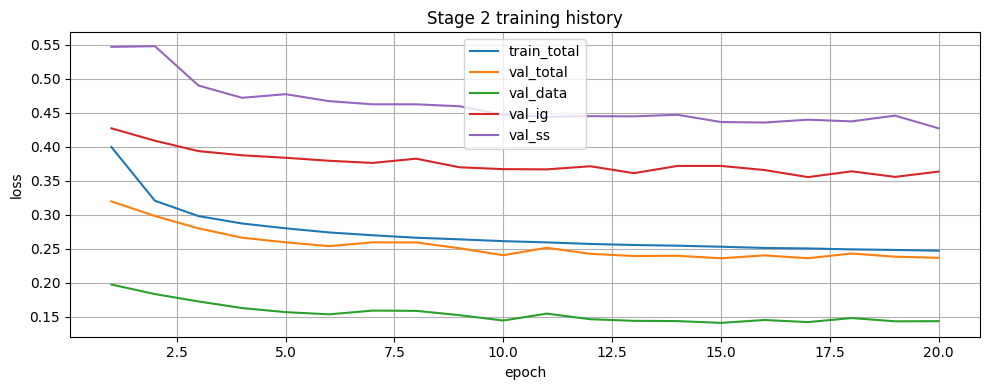

In [9]:

# =========================
# Stage 2: conditional TCN
# =========================

def shift_trace_batch_grid(seq, dt, shift_seconds):
    # seq: [B, T]
    # dt: [B]
    # shift_seconds: [B]
    B, T = seq.shape
    device = seq.device
    dtype = seq.dtype

    t_idx = torch.arange(T, device=device, dtype=dtype)[None, :]
    dtv = dt.to(dtype).reshape(B, 1)
    shifts = shift_seconds.to(dtype).reshape(B, 1)

    src_idx = t_idx - shifts / dtv
    if T > 1:
        x_norm = 2.0 * src_idx / (T - 1) - 1.0
    else:
        x_norm = torch.zeros_like(src_idx)

    y_norm = torch.zeros_like(x_norm)
    grid = torch.stack([x_norm, y_norm], dim=-1).unsqueeze(1)  # [B, 1, T, 2]

    inp = seq.unsqueeze(1).unsqueeze(2)  # [B, 1, 1, T]
    out = F.grid_sample(
        inp,
        grid,
        mode="bilinear",
        padding_mode="border",
        align_corners=True,
    )
    return out[:, 0, 0, :]

class FiLM(nn.Module):
    def __init__(self, static_dim, channels):
        super().__init__()
        hidden = max(channels, 16)
        self.net = nn.Sequential(
            nn.Linear(static_dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, 2 * channels),
        )

    def forward(self, x, static):
        gamma_beta = self.net(static)
        gamma, beta = gamma_beta.chunk(2, dim=-1)
        return x * (1.0 + gamma[..., None]) + beta[..., None]

class ResidualTCNBlock(nn.Module):
    def __init__(self, channels, static_dim, kernel_size=5, dilation=1, dropout=0.0):
        super().__init__()
        pad = dilation * (kernel_size // 2)

        groups = max(1, min(8, channels))
        while channels % groups != 0 and groups > 1:
            groups -= 1

        self.conv1 = nn.Conv1d(
            channels,
            channels,
            kernel_size=kernel_size,
            padding=pad,
            dilation=dilation,
            padding_mode="reflect",
        )
        self.conv2 = nn.Conv1d(
            channels,
            channels,
            kernel_size=kernel_size,
            padding=pad,
            dilation=dilation,
            padding_mode="reflect",
        )

        self.norm1 = nn.GroupNorm(groups, channels)
        self.norm2 = nn.GroupNorm(groups, channels)

        self.film1 = FiLM(static_dim, channels)
        self.film2 = FiLM(static_dim, channels)

        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x, static):
        h = self.conv1(x)
        h = self.norm1(h)
        h = self.film1(h, static)
        h = F.gelu(h)
        h = self.dropout(h)

        h = self.conv2(h)
        h = self.norm2(h)
        h = self.film2(h, static)
        h = F.gelu(h)
        h = self.dropout(h)

        return x + h

class FullSequenceCondTCN(nn.Module):
    def __init__(self, in_channels, static_dim, hidden_channels=64, kernel_size=5, dilations=(1, 2, 4, 8, 16, 32, 64, 128), dropout=0.05):
        super().__init__()
        groups = max(1, min(8, hidden_channels))
        while hidden_channels % groups != 0 and groups > 1:
            groups -= 1

        self.input_proj = nn.Conv1d(in_channels, hidden_channels, kernel_size=1)
        self.blocks = nn.ModuleList([
            ResidualTCNBlock(
                channels=hidden_channels,
                static_dim=static_dim,
                kernel_size=kernel_size,
                dilation=int(d),
                dropout=dropout,
            )
            for d in dilations
        ])
        self.out = nn.Sequential(
            nn.GroupNorm(groups, hidden_channels),
            nn.GELU(),
            nn.Conv1d(hidden_channels, hidden_channels, kernel_size=1),
            nn.GELU(),
            nn.Conv1d(hidden_channels, 1, kernel_size=1),
        )

    def forward(self, seq, static):
        x = self.input_proj(seq)
        for blk in self.blocks:
            x = blk(x, static)
        return self.out(x).squeeze(1)

def masked_huber_loss(pred, target, mask, delta=1.0):
    diff = pred - target
    abs_diff = diff.abs()
    loss = torch.where(
        abs_diff <= delta,
        0.5 * diff ** 2,
        delta * (abs_diff - 0.5 * delta),
    )
    loss = loss * mask
    denom = mask.sum().clamp_min(1.0)
    return loss.sum() / denom

def masked_corr_loss(pred, target, mask, eps=1e-6):
    losses = []
    for i in range(pred.shape[0]):
        m = mask[i] > 0.5
        if m.sum() < 8:
            continue
        p = pred[i, m]
        y = target[i, m]
        p = p - p.mean()
        y = y - y.mean()
        denom = torch.sqrt((p ** 2).mean() + eps) * torch.sqrt((y ** 2).mean() + eps)
        corr = (p * y).mean() / denom
        losses.append(1.0 - corr)

    if len(losses) == 0:
        return pred.new_tensor(0.0)
    return torch.stack(losses).mean()

def spectral_band_loss_torch(pred, target, mask, dt, bands=((0.004, 0.04), (0.04, 0.5)), eps=1e-6):
    losses = {f"band_{i}": [] for i in range(len(bands))}

    for i in range(pred.shape[0]):
        m = mask[i] > 0.5
        if m.sum() < 32:
            continue

        p = pred[i, m] - pred[i, m].mean()
        y = target[i, m] - target[i, m].mean()

        win = torch.hann_window(len(p), device=p.device, dtype=p.dtype)
        P = torch.fft.rfft(p * win)
        Y = torch.fft.rfft(y * win)
        freqs = torch.fft.rfftfreq(len(p), d=float(dt[i].item())).to(p.device)

        for j, (f0, f1) in enumerate(bands):
            keep = (freqs >= f0) & (freqs < f1)
            if keep.sum() == 0:
                continue

            diff = torch.abs(torch.abs(P[keep]) - torch.abs(Y[keep]))
            denom = torch.abs(Y[keep]).mean().clamp_min(eps)
            losses[f"band_{j}"].append(diff.mean() / denom)

    out = {}
    for k, v in losses.items():
        out[k] = torch.stack(v).mean() if len(v) > 0 else pred.new_tensor(0.0)
    return out

def prepare_single_sample_tensors(item, station, scalers, channel_schema, feature_schema, device=DEVICE):
    X = build_time_channels_from_item(item, station, channel_schema)
    static = build_static_features_from_item(item, station, feature_schema)

    X = (X - scalers["channel_mean"][:, None]) / scalers["channel_std"][:, None]
    static = (static - scalers["static_mean"]) / scalers["static_std"]

    y = station["target"].astype(np.float32)
    mask = station["target_mask"].astype(np.float32)

    offshore_target_scaled = ((item["offshore"].astype(np.float32) - scalers["target_mean"]) / scalers["target_std"]).astype(np.float32)
    physics_baseline_target_scaled = ((station["physics_baseline"].astype(np.float32) - scalers["target_mean"]) / scalers["target_std"]).astype(np.float32)
    delay_trace_target_scaled = ((station["delay_trace"].astype(np.float32) - scalers["target_mean"]) / scalers["target_std"]).astype(np.float32)

    batch = {
        "input_seq": torch.tensor(X[None, ...], dtype=torch.float32, device=device),
        "static": torch.tensor(static[None, ...], dtype=torch.float32, device=device),
        "target": torch.tensor(((y - scalers["target_mean"]) / scalers["target_std"])[None, ...], dtype=torch.float32, device=device),
        "mask": torch.tensor(mask[None, ...], dtype=torch.float32, device=device),
        "offshore_target_scaled": torch.tensor(offshore_target_scaled[None, ...], dtype=torch.float32, device=device),
        "physics_baseline_target_scaled": torch.tensor(physics_baseline_target_scaled[None, ...], dtype=torch.float32, device=device),
        "delay_trace_target_scaled": torch.tensor(delay_trace_target_scaled[None, ...], dtype=torch.float32, device=device),
        "dt": torch.tensor([item["dt"]], dtype=torch.float32, device=device),
        "tau_path_raw": torch.tensor([station["tau_path"]], dtype=torch.float32, device=device),
        "shoaling_gain_raw": torch.tensor([station["shoaling_gain_path"]], dtype=torch.float32, device=device),
    }
    return batch

def stage2_forward_and_loss(model, batch, device, cfg):
    seq = batch["input_seq"].to(device)
    static = batch["static"].to(device)
    target = batch["target"].to(device)
    mask = batch["mask"].to(device)
    dt = batch["dt"].to(device)

    pred = model(seq, static)

    l_data = masked_huber_loss(pred, target, mask, delta=1.0)
    l_corr = masked_corr_loss(pred, target, mask)
    l_spec = spectral_band_loss_torch(pred, target, mask, dt)

    loss = (
        l_data
        + cfg["corr_loss_weight"] * l_corr
        + cfg["ig_loss_weight"] * l_spec["band_0"]
        + cfg["ss_loss_weight"] * l_spec["band_1"]
    )

    stats = {
        "data": float(l_data.item()),
        "corr": float(l_corr.item()),
        "ig": float(l_spec["band_0"].item()),
        "ss": float(l_spec["band_1"].item()),
        "total": float(loss.item()),
    }
    return loss, stats

def train_torch_sequence_model(model, train_loader, val_loader, forward_and_loss_fn, epochs, patience, learning_rate, weight_decay, device, stage_label="model"):
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    history_rows = []
    best_val = np.inf
    best_state = None
    bad_epochs = 0

    for epoch in range(1, epochs + 1):
        if hasattr(train_loader.batch_sampler, "set_epoch"):
            train_loader.batch_sampler.set_epoch(epoch)

        model.train()
        train_acc = {"total": 0.0, "data": 0.0, "corr": 0.0, "ig": 0.0, "ss": 0.0, "count": 0}

        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            loss, stats = forward_and_loss_fn(model, batch, device)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            train_acc["total"] += stats["total"]
            train_acc["data"] += stats["data"]
            train_acc["corr"] += stats["corr"]
            train_acc["ig"] += stats["ig"]
            train_acc["ss"] += stats["ss"]
            train_acc["count"] += 1

        model.eval()
        val_acc = {"total": 0.0, "data": 0.0, "corr": 0.0, "ig": 0.0, "ss": 0.0, "count": 0}

        with torch.no_grad():
            for batch in val_loader:
                loss, stats = forward_and_loss_fn(model, batch, device)
                val_acc["total"] += stats["total"]
                val_acc["data"] += stats["data"]
                val_acc["corr"] += stats["corr"]
                val_acc["ig"] += stats["ig"]
                val_acc["ss"] += stats["ss"]
                val_acc["count"] += 1

        train_row = {f"train_{k}": train_acc[k] / max(train_acc["count"], 1) for k in ["total", "data", "corr", "ig", "ss"]}
        val_row = {f"val_{k}": val_acc[k] / max(val_acc["count"], 1) for k in ["total", "data", "corr", "ig", "ss"]}

        row = {"epoch": epoch, **train_row, **val_row}
        history_rows.append(row)

        print(
            f"[{stage_label}] epoch {epoch:03d} | "
            f"train={row['train_total']:.4f} | val={row['val_total']:.4f}"
        )

        if row["val_total"] < best_val - 1e-5:
            best_val = row["val_total"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print(f"Early stop for {stage_label} at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history_rows)
    return model, history_df

def predict_stage2_raw(item, station, stage2_bundle, device=DEVICE):
    model = stage2_bundle["model"].to(device)
    model.eval()

    batch = prepare_single_sample_tensors(
        item=item,
        station=station,
        scalers=stage2_bundle["scalers"],
        channel_schema=stage2_bundle["channel_schema"],
        feature_schema=stage2_bundle["feature_schema"],
        device=device,
    )

    with torch.no_grad():
        pred_std = model(batch["input_seq"], batch["static"]).squeeze(0).cpu().numpy()

    return inverse_scale_target(pred_std, stage2_bundle["scalers"]).astype(np.float32)

stage2_bundle = None
stage2_history_df = None

if RUN_STAGE2:
    scalers_stage2 = fit_scalers_for_stage(
        run_registry=run_registry,
        sample_manifest_df=sample_manifest_df,
        indices=train_idx,
        channel_schema=cfg["stage2_channel_schema"],
        feature_schema=cfg["stage2_feature_schema"],
        mmap_mode=mmap_mode,
    )

    train_ds_stage2 = StationSequenceDataset(
        run_registry=run_registry,
        sample_manifest_df=sample_manifest_df,
        indices=train_idx,
        scalers=scalers_stage2,
        channel_schema=cfg["stage2_channel_schema"],
        feature_schema=cfg["stage2_feature_schema"],
        mmap_mode=mmap_mode,
    )
    val_ds_stage2 = StationSequenceDataset(
        run_registry=run_registry,
        sample_manifest_df=sample_manifest_df,
        indices=val_idx,
        scalers=scalers_stage2,
        channel_schema=cfg["stage2_channel_schema"],
        feature_schema=cfg["stage2_feature_schema"],
        mmap_mode=mmap_mode,
    )

    train_loader_stage2 = make_loader(train_ds_stage2, batch_size=cfg["stage2_batch_size"], shuffle=True)
    val_loader_stage2 = make_loader(val_ds_stage2, batch_size=cfg["stage2_batch_size"], shuffle=False)

    model_stage2 = FullSequenceCondTCN(
        in_channels=len(TIME_CHANNEL_SCHEMAS[cfg["stage2_channel_schema"]]),
        static_dim=len(FEATURE_SCHEMAS[cfg["stage2_feature_schema"]]),
        hidden_channels=cfg["stage2_hidden_channels"],
        kernel_size=cfg["stage2_kernel_size"],
        dilations=tuple(cfg["stage2_dilations"]),
        dropout=cfg["stage2_dropout"],
    )

    model_stage2, stage2_history_df = train_torch_sequence_model(
        model=model_stage2,
        train_loader=train_loader_stage2,
        val_loader=val_loader_stage2,
        forward_and_loss_fn=lambda m, b, d: stage2_forward_and_loss(m, b, d, cfg),
        epochs=cfg["stage2_epochs"],
        patience=cfg["stage2_patience"],
        learning_rate=cfg["stage2_learning_rate"],
        weight_decay=cfg["stage2_weight_decay"],
        device=DEVICE,
        stage_label="Stage2",
    )

    stage2_bundle = {
        "model": model_stage2,
        "scalers": scalers_stage2,
        "channel_schema": cfg["stage2_channel_schema"],
        "feature_schema": cfg["stage2_feature_schema"],
        "model_config": {
            "in_channels": len(TIME_CHANNEL_SCHEMAS[cfg["stage2_channel_schema"]]),
            "static_dim": len(FEATURE_SCHEMAS[cfg["stage2_feature_schema"]]),
            "hidden_channels": cfg["stage2_hidden_channels"],
            "kernel_size": cfg["stage2_kernel_size"],
            "dilations": list(cfg["stage2_dilations"]),
            "dropout": cfg["stage2_dropout"],
        },
    }

    if SAVE_MODEL_BUNDLES:
        torch.save(
            {
                "model_state_dict": model_stage2.state_dict(),
                "scalers": scalers_stage2,
                "channel_schema": cfg["stage2_channel_schema"],
                "feature_schema": cfg["stage2_feature_schema"],
                "model_config": stage2_bundle["model_config"],
            },
            MODEL_ROOT / "stage2_fullseq_tcn_bundle.pt",
        )

    plt.figure(figsize=(10, 4))
    plt.plot(stage2_history_df["epoch"], stage2_history_df["train_total"], label="train_total")
    plt.plot(stage2_history_df["epoch"], stage2_history_df["val_total"], label="val_total")
    plt.plot(stage2_history_df["epoch"], stage2_history_df["val_data"], label="val_data")
    plt.plot(stage2_history_df["epoch"], stage2_history_df["val_ig"], label="val_ig")
    plt.plot(stage2_history_df["epoch"], stage2_history_df["val_ss"], label="val_ss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Stage 2 training history")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_ROOT / "stage2_training_history.png", dpi=150, bbox_inches="tight")
    plt.show()



## Stage 3 — physics-informed residual hybrid

This stage adds an explicit physics-inspired layer:

- start from the offshore signal
- apply a **differentiable travel-time shift**
- apply a **shoaling gain**
- allow only **small learned corrections** to those physics parameters
- let the neural network predict the **residual**

Final prediction:

$\eta_{\text{pred}}(t) = \eta_{\text{physics}}(t) + \eta_{\text{residual}}(t)$

This is a more practical approach than a full PDE PINN, but still gives a genuine physics-guided model stage.


Fit scalers [physics_augmented | with_physics_aux]: 100%|██████████| 35010/35010 [00:04<00:00, 8695.29it/s]


[Stage3] epoch 001 | train=0.2368 | val=0.1779
[Stage3] epoch 002 | train=0.1744 | val=0.1617
[Stage3] epoch 003 | train=0.1597 | val=0.1473
[Stage3] epoch 004 | train=0.1509 | val=0.1406
[Stage3] epoch 005 | train=0.1454 | val=0.1307
[Stage3] epoch 006 | train=0.1414 | val=0.1369
[Stage3] epoch 007 | train=0.1385 | val=0.1328
[Stage3] epoch 008 | train=0.1361 | val=0.1274
[Stage3] epoch 009 | train=0.1338 | val=0.1238
[Stage3] epoch 010 | train=0.1320 | val=0.1245
[Stage3] epoch 011 | train=0.1308 | val=0.1285
[Stage3] epoch 012 | train=0.1296 | val=0.1241
[Stage3] epoch 013 | train=0.1284 | val=0.1281
[Stage3] epoch 014 | train=0.1273 | val=0.1216
[Stage3] epoch 015 | train=0.1259 | val=0.1206
[Stage3] epoch 016 | train=0.1253 | val=0.1177
[Stage3] epoch 017 | train=0.1250 | val=0.1158
[Stage3] epoch 018 | train=0.1236 | val=0.1171
[Stage3] epoch 019 | train=0.1233 | val=0.1190
[Stage3] epoch 020 | train=0.1226 | val=0.1173
[Stage3] epoch 021 | train=0.1218 | val=0.1159
[Stage3] epoc

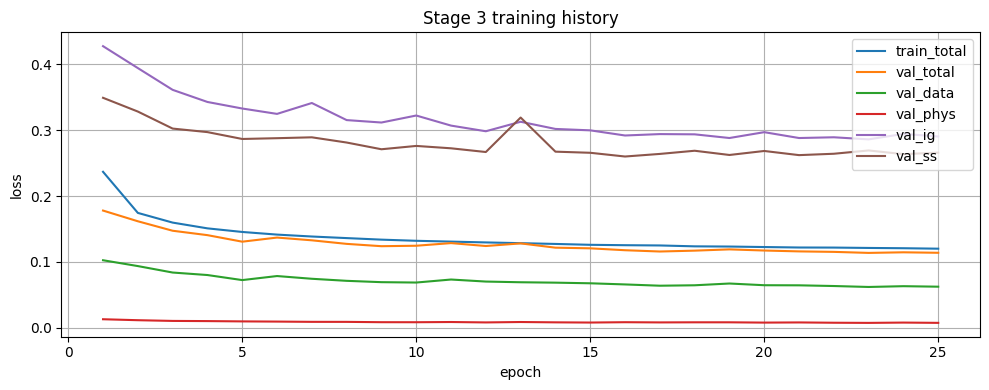

In [10]:

# =========================
# Stage 3: physics-informed hybrid
# =========================

class DifferentiableLinearPhysicsLayer(nn.Module):
    def __init__(self, static_dim, tau_rel_limit=0.25, gain_rel_limit=0.20):
        super().__init__()
        hidden = max(16, static_dim * 4)
        self.net = nn.Sequential(
            nn.Linear(static_dim, hidden),
            nn.GELU(),
            nn.Linear(hidden, 2),
        )
        self.tau_rel_limit = float(tau_rel_limit)
        self.gain_rel_limit = float(gain_rel_limit)

    def forward(self, offshore_target_scaled, static, dt, tau_path_raw, shoaling_gain_raw):
        params = self.net(static)

        tau_corr = self.tau_rel_limit * torch.tanh(params[:, 0]) * tau_path_raw
        gain_corr = 1.0 + self.gain_rel_limit * torch.tanh(params[:, 1])

        tau_total = tau_path_raw + tau_corr
        gain_total = shoaling_gain_raw * gain_corr

        shifted = shift_trace_batch_grid(
            seq=offshore_target_scaled,
            dt=dt,
            shift_seconds=tau_total,
        )
        y_phys = gain_total[:, None] * shifted

        reg = (
            (tau_corr / tau_path_raw.abs().clamp_min(1.0)) ** 2 +
            (gain_corr - 1.0) ** 2
        ).mean()

        aux = {
            "tau_total": tau_total,
            "gain_total": gain_total,
            "tau_corr": tau_corr,
            "gain_corr": gain_corr,
        }
        return y_phys, reg, aux

class PhysicsResidualTCN(nn.Module):
    def __init__(self, in_channels, static_dim, hidden_channels=64, kernel_size=5, dilations=(1, 2, 4, 8, 16, 32, 64, 128), dropout=0.05):
        super().__init__()
        self.physics = DifferentiableLinearPhysicsLayer(static_dim=static_dim)
        self.residual_net = FullSequenceCondTCN(
            in_channels=in_channels + 1,  # append physics baseline as one extra channel
            static_dim=static_dim,
            hidden_channels=hidden_channels,
            kernel_size=kernel_size,
            dilations=dilations,
            dropout=dropout,
        )

    def forward(self, seq, static, offshore_target_scaled, dt, tau_path_raw, shoaling_gain_raw):
        y_phys, physics_reg, aux = self.physics(
            offshore_target_scaled=offshore_target_scaled,
            static=static,
            dt=dt,
            tau_path_raw=tau_path_raw,
            shoaling_gain_raw=shoaling_gain_raw,
        )

        seq_aug = torch.cat([seq, y_phys.unsqueeze(1)], dim=1)
        residual = self.residual_net(seq_aug, static)
        pred = y_phys + residual

        aux_out = {
            "physics_reg": physics_reg,
            "physics_baseline": y_phys,
            "residual": residual,
            **aux,
        }
        return pred, aux_out

def stage3_forward_and_loss(model, batch, device, cfg):
    seq = batch["input_seq"].to(device)
    static = batch["static"].to(device)
    target = batch["target"].to(device)
    mask = batch["mask"].to(device)

    offshore_target_scaled = batch["offshore_target_scaled"].to(device)
    dt = batch["dt"].to(device)
    tau_path_raw = batch["tau_path_raw"].to(device)
    shoaling_gain_raw = batch["shoaling_gain_raw"].to(device)

    pred, aux = model(
        seq=seq,
        static=static,
        offshore_target_scaled=offshore_target_scaled,
        dt=dt,
        tau_path_raw=tau_path_raw,
        shoaling_gain_raw=shoaling_gain_raw,
    )

    l_data = masked_huber_loss(pred, target, mask, delta=1.0)
    l_corr = masked_corr_loss(pred, target, mask)
    l_spec = spectral_band_loss_torch(pred, target, mask, dt)
    l_phys = aux["physics_reg"]

    loss = (
        l_data
        + cfg["corr_loss_weight"] * l_corr
        + cfg["ig_loss_weight"] * l_spec["band_0"]
        + cfg["ss_loss_weight"] * l_spec["band_1"]
        + cfg["physics_reg_weight"] * l_phys
    )

    stats = {
        "data": float(l_data.item()),
        "corr": float(l_corr.item()),
        "ig": float(l_spec["band_0"].item()),
        "ss": float(l_spec["band_1"].item()),
        "phys": float(l_phys.item()),
        "total": float(loss.item()),
    }
    return loss, stats

def train_stage3_model(model, train_loader, val_loader, cfg, device=DEVICE):
    model = model.to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=cfg["stage3_learning_rate"],
        weight_decay=cfg["stage3_weight_decay"],
    )

    history_rows = []
    best_val = np.inf
    best_state = None
    bad_epochs = 0

    for epoch in range(1, cfg["stage3_epochs"] + 1):
        if hasattr(train_loader.batch_sampler, "set_epoch"):
            train_loader.batch_sampler.set_epoch(epoch)

        model.train()
        train_acc = {"total": 0.0, "data": 0.0, "corr": 0.0, "ig": 0.0, "ss": 0.0, "phys": 0.0, "count": 0}

        for batch in train_loader:
            optimizer.zero_grad(set_to_none=True)
            loss, stats = stage3_forward_and_loss(model, batch, device, cfg)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            for k in ["total", "data", "corr", "ig", "ss", "phys"]:
                train_acc[k] += stats[k]
            train_acc["count"] += 1

        model.eval()
        val_acc = {"total": 0.0, "data": 0.0, "corr": 0.0, "ig": 0.0, "ss": 0.0, "phys": 0.0, "count": 0}

        with torch.no_grad():
            for batch in val_loader:
                loss, stats = stage3_forward_and_loss(model, batch, device, cfg)
                for k in ["total", "data", "corr", "ig", "ss", "phys"]:
                    val_acc[k] += stats[k]
                val_acc["count"] += 1

        row = {
            "epoch": epoch,
            "train_total": train_acc["total"] / max(train_acc["count"], 1),
            "train_data": train_acc["data"] / max(train_acc["count"], 1),
            "train_corr": train_acc["corr"] / max(train_acc["count"], 1),
            "train_ig": train_acc["ig"] / max(train_acc["count"], 1),
            "train_ss": train_acc["ss"] / max(train_acc["count"], 1),
            "train_phys": train_acc["phys"] / max(train_acc["count"], 1),
            "val_total": val_acc["total"] / max(val_acc["count"], 1),
            "val_data": val_acc["data"] / max(val_acc["count"], 1),
            "val_corr": val_acc["corr"] / max(val_acc["count"], 1),
            "val_ig": val_acc["ig"] / max(val_acc["count"], 1),
            "val_ss": val_acc["ss"] / max(val_acc["count"], 1),
            "val_phys": val_acc["phys"] / max(val_acc["count"], 1),
        }
        history_rows.append(row)

        print(
            f"[Stage3] epoch {epoch:03d} | "
            f"train={row['train_total']:.4f} | val={row['val_total']:.4f}"
        )

        if row["val_total"] < best_val - 1e-5:
            best_val = row["val_total"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= cfg["stage3_patience"]:
                print(f"Early stop for Stage3 at epoch {epoch}")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history_rows)
    return model, history_df

def predict_stage3_raw(item, station, stage3_bundle, device=DEVICE):
    model = stage3_bundle["model"].to(device)
    model.eval()

    batch = prepare_single_sample_tensors(
        item=item,
        station=station,
        scalers=stage3_bundle["scalers"],
        channel_schema=stage3_bundle["channel_schema"],
        feature_schema=stage3_bundle["feature_schema"],
        device=device,
    )

    with torch.no_grad():
        pred_std, aux = model(
            seq=batch["input_seq"],
            static=batch["static"],
            offshore_target_scaled=batch["offshore_target_scaled"],
            dt=batch["dt"],
            tau_path_raw=batch["tau_path_raw"],
            shoaling_gain_raw=batch["shoaling_gain_raw"],
        )
        pred_std = pred_std.squeeze(0).cpu().numpy()

    return inverse_scale_target(pred_std, stage3_bundle["scalers"]).astype(np.float32)

def predict_physics_baseline_raw(item, station):
    return np.asarray(station["physics_baseline"], dtype=np.float32).copy()

stage3_bundle = None
stage3_history_df = None

if RUN_STAGE3:
    scalers_stage3 = fit_scalers_for_stage(
        run_registry=run_registry,
        sample_manifest_df=sample_manifest_df,
        indices=train_idx,
        channel_schema=cfg["stage3_channel_schema"],
        feature_schema=cfg["stage3_feature_schema"],
        mmap_mode=mmap_mode,
    )

    train_ds_stage3 = StationSequenceDataset(
        run_registry=run_registry,
        sample_manifest_df=sample_manifest_df,
        indices=train_idx,
        scalers=scalers_stage3,
        channel_schema=cfg["stage3_channel_schema"],
        feature_schema=cfg["stage3_feature_schema"],
        mmap_mode=mmap_mode,
    )
    val_ds_stage3 = StationSequenceDataset(
        run_registry=run_registry,
        sample_manifest_df=sample_manifest_df,
        indices=val_idx,
        scalers=scalers_stage3,
        channel_schema=cfg["stage3_channel_schema"],
        feature_schema=cfg["stage3_feature_schema"],
        mmap_mode=mmap_mode,
    )

    train_loader_stage3 = make_loader(train_ds_stage3, batch_size=cfg["stage3_batch_size"], shuffle=True)
    val_loader_stage3 = make_loader(val_ds_stage3, batch_size=cfg["stage3_batch_size"], shuffle=False)

    model_stage3 = PhysicsResidualTCN(
        in_channels=len(TIME_CHANNEL_SCHEMAS[cfg["stage3_channel_schema"]]),
        static_dim=len(FEATURE_SCHEMAS[cfg["stage3_feature_schema"]]),
        hidden_channels=cfg["stage3_hidden_channels"],
        kernel_size=cfg["stage3_kernel_size"],
        dilations=tuple(cfg["stage3_dilations"]),
        dropout=cfg["stage3_dropout"],
    )

    model_stage3, stage3_history_df = train_stage3_model(
        model=model_stage3,
        train_loader=train_loader_stage3,
        val_loader=val_loader_stage3,
        cfg=cfg,
        device=DEVICE,
    )

    stage3_bundle = {
        "model": model_stage3,
        "scalers": scalers_stage3,
        "channel_schema": cfg["stage3_channel_schema"],
        "feature_schema": cfg["stage3_feature_schema"],
        "model_config": {
            "in_channels": len(TIME_CHANNEL_SCHEMAS[cfg["stage3_channel_schema"]]),
            "static_dim": len(FEATURE_SCHEMAS[cfg["stage3_feature_schema"]]),
            "hidden_channels": cfg["stage3_hidden_channels"],
            "kernel_size": cfg["stage3_kernel_size"],
            "dilations": list(cfg["stage3_dilations"]),
            "dropout": cfg["stage3_dropout"],
        },
    }

    if SAVE_MODEL_BUNDLES:
        torch.save(
            {
                "model_state_dict": model_stage3.state_dict(),
                "scalers": scalers_stage3,
                "channel_schema": cfg["stage3_channel_schema"],
                "feature_schema": cfg["stage3_feature_schema"],
                "model_config": stage3_bundle["model_config"],
            },
            MODEL_ROOT / "stage3_physics_hybrid_bundle.pt",
        )

    plt.figure(figsize=(10, 4))
    plt.plot(stage3_history_df["epoch"], stage3_history_df["train_total"], label="train_total")
    plt.plot(stage3_history_df["epoch"], stage3_history_df["val_total"], label="val_total")
    plt.plot(stage3_history_df["epoch"], stage3_history_df["val_data"], label="val_data")
    plt.plot(stage3_history_df["epoch"], stage3_history_df["val_phys"], label="val_phys")
    plt.plot(stage3_history_df["epoch"], stage3_history_df["val_ig"], label="val_ig")
    plt.plot(stage3_history_df["epoch"], stage3_history_df["val_ss"], label="val_ss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title("Stage 3 training history")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_ROOT / "stage3_training_history.png", dpi=150, bbox_inches="tight")
    plt.show()



## Model comparison on the held-out test split

The comparison includes:

- **physics_baseline**: delay + shoaling only
- **stage1_ridge**
- **stage2_tcn**
- **stage3_hybrid**

Metrics reported:
- RMSE
- MAE
- \(R^2\)
- correlation
- mean absolute lag in seconds
- relative band-energy error in:
  - infragravity band: `0.004–0.04 Hz`
  - sea-swell band: `0.04–0.5 Hz`


Evaluate stage3_hybrid: 100%|██████████| 7390/7390 [02:04<00:00, 59.43it/s]


,model,rmse,mae,r2,corr,lag_abs_seconds,band_rel_err_0,band_rel_err_1
0,physics_baseline,0.422876,0.334797,-27.815432,0.028193,4.844411,3.029293,81.989443
1,stage1_ridge,0.255498,0.206427,-8.618818,0.136498,20.315237,0.993268,1.104409
2,stage2_tcn,0.139512,0.106934,-1.398722,0.683857,0.985007,0.364138,0.428453
3,stage3_hybrid,0.086218,0.065056,-1.968542,0.890606,0.230501,0.237368,0.179369


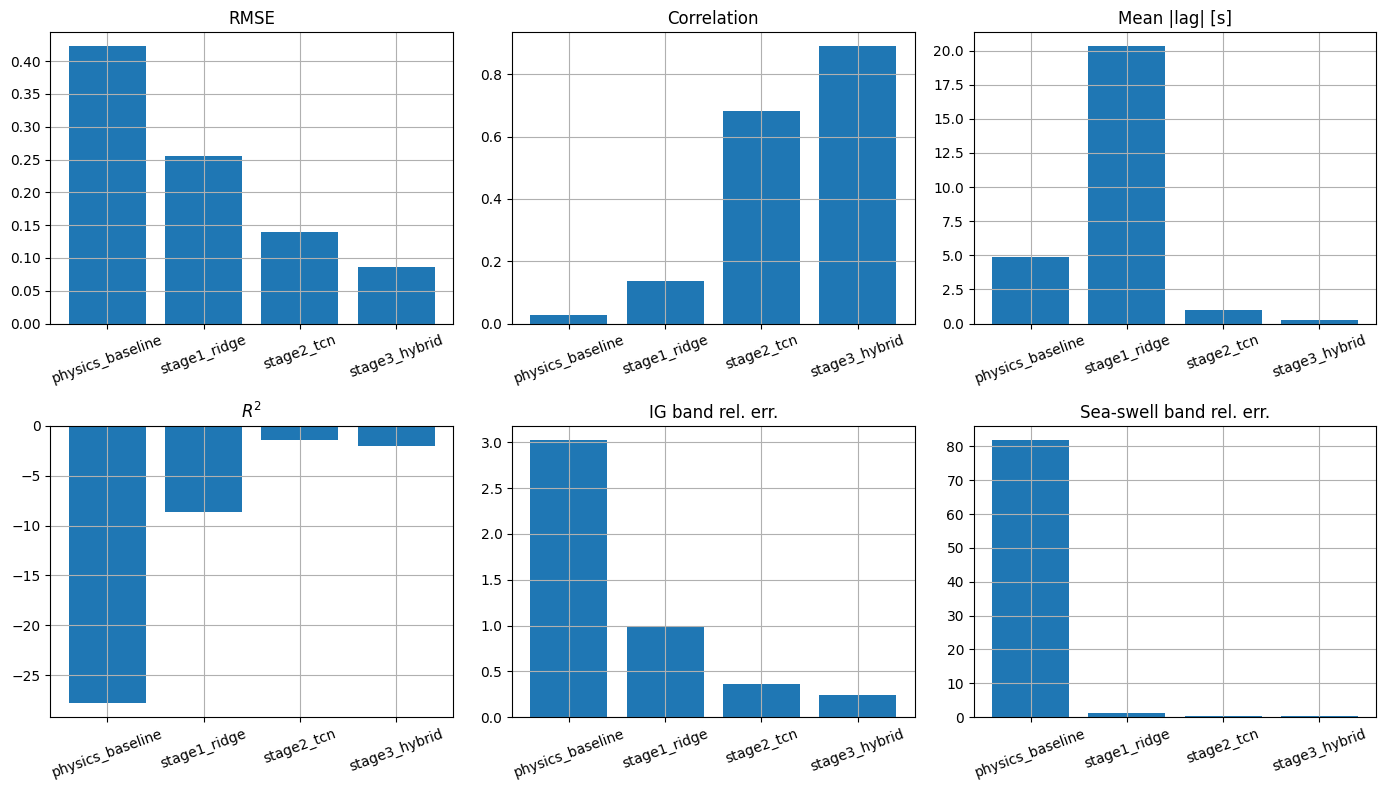

,model,depth_bin,rmse,corr,r2,lag_abs_seconds
0,physics_baseline,<=1m,0.893199,0.025596,-259.697745,9.594444
1,physics_baseline,1-2m,0.393194,-0.095094,-3.480447,8.124590
2,physics_baseline,2-4m,0.406919,-0.151419,-2.255861,6.286347
3,physics_baseline,4-6m,0.405398,-0.127843,-1.528769,4.639828
4,physics_baseline,>6m,0.304948,0.321145,-0.393151,2.122377
5,stage1_ridge,<=1m,0.331558,-0.002078,-84.419330,16.878571
6,stage1_ridge,1-2m,0.191920,-0.003203,-0.051538,25.160656
7,stage1_ridge,2-4m,0.227095,0.016628,-0.029062,26.006273
8,stage1_ridge,4-6m,0.255215,0.083144,0.000489,27.811159
9,stage1_ridge,>6m,0.259178,0.333124,0.079977,9.527686


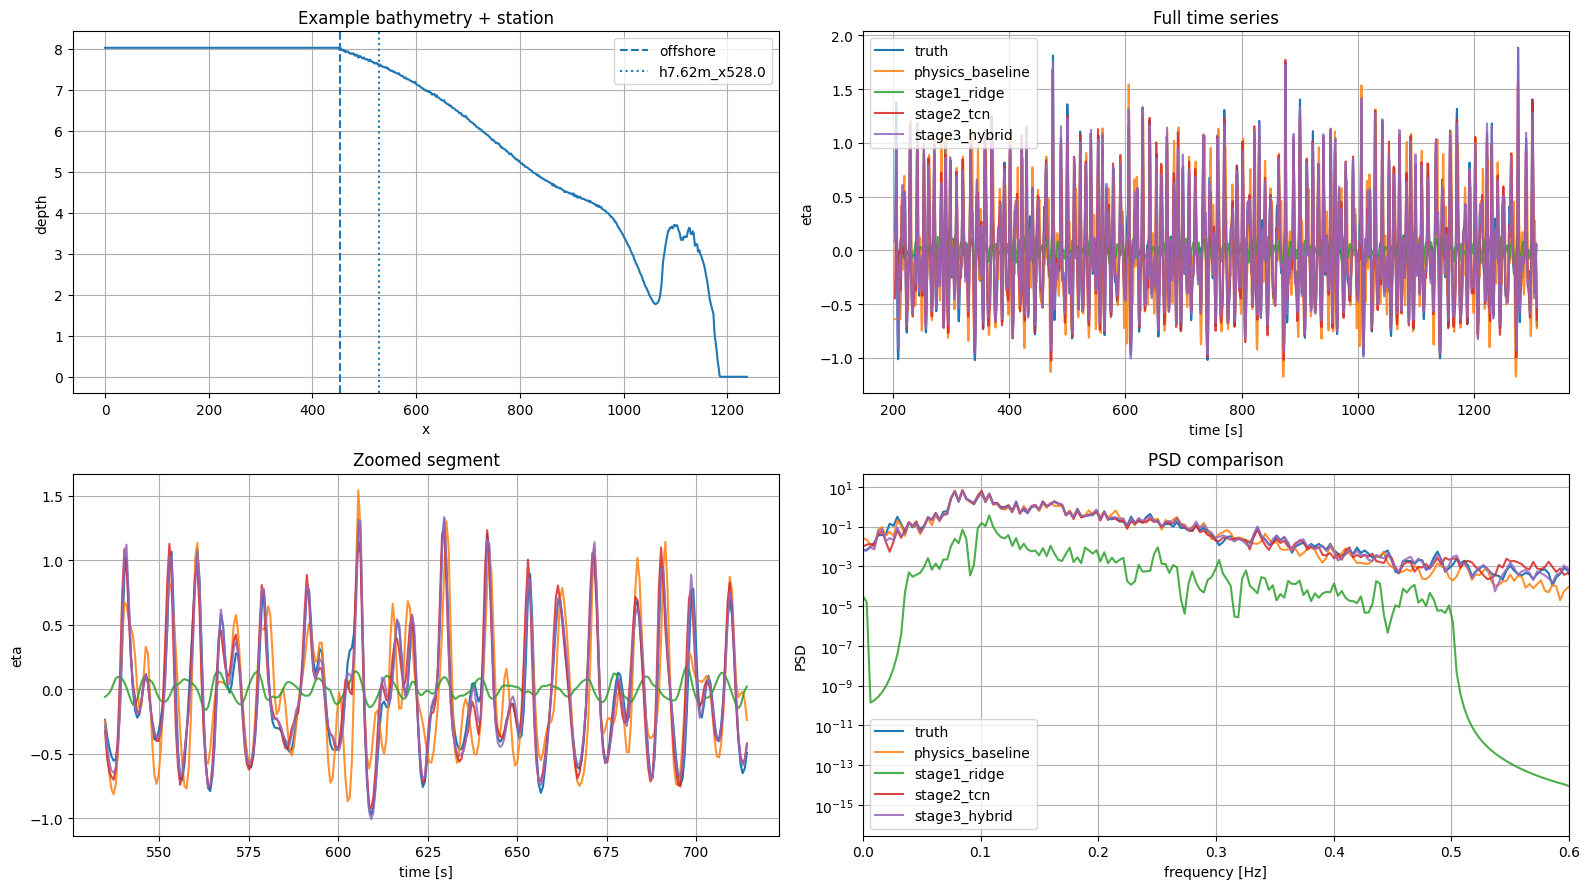

In [11]:

comparison_tables = []

physics_baseline_df = evaluate_predictor(
    indices=test_idx,
    predictor_fn=lambda item, station: predict_physics_baseline_raw(item, station),
    label="physics_baseline",
    run_registry=run_registry,
    sample_manifest_df=sample_manifest_df,
    mmap_mode=mmap_mode,
)
comparison_tables.append(physics_baseline_df)

if stage1_bundle is not None:
    stage1_df = evaluate_predictor(
        indices=test_idx,
        predictor_fn=lambda item, station: predict_stage1_raw(item, station, stage1_bundle),
        label="stage1_ridge",
        run_registry=run_registry,
        sample_manifest_df=sample_manifest_df,
        mmap_mode=mmap_mode,
    )
    comparison_tables.append(stage1_df)

if stage2_bundle is not None:
    stage2_df = evaluate_predictor(
        indices=test_idx,
        predictor_fn=lambda item, station: predict_stage2_raw(item, station, stage2_bundle, device=DEVICE),
        label="stage2_tcn",
        run_registry=run_registry,
        sample_manifest_df=sample_manifest_df,
        mmap_mode=mmap_mode,
    )
    comparison_tables.append(stage2_df)

if stage3_bundle is not None:
    stage3_df = evaluate_predictor(
        indices=test_idx,
        predictor_fn=lambda item, station: predict_stage3_raw(item, station, stage3_bundle, device=DEVICE),
        label="stage3_hybrid",
        run_registry=run_registry,
        sample_manifest_df=sample_manifest_df,
        mmap_mode=mmap_mode,
    )
    comparison_tables.append(stage3_df)

comparison_df = pd.concat(comparison_tables, ignore_index=True)
comparison_df.to_csv(TABLE_ROOT / "test_comparison_per_sample.csv", index=False)

summary_df = comparison_df.groupby("model")[[
    "rmse", "mae", "r2", "corr", "lag_abs_seconds", "band_rel_err_0", "band_rel_err_1"
]].mean().reset_index()

summary_df.to_csv(TABLE_ROOT / "test_comparison_summary.csv", index=False)

display(summary_df)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].bar(summary_df["model"], summary_df["rmse"])
axes[0, 0].set_title("RMSE")
axes[0, 0].tick_params(axis="x", rotation=20)

axes[0, 1].bar(summary_df["model"], summary_df["corr"])
axes[0, 1].set_title("Correlation")
axes[0, 1].tick_params(axis="x", rotation=20)

axes[0, 2].bar(summary_df["model"], summary_df["lag_abs_seconds"])
axes[0, 2].set_title("Mean |lag| [s]")
axes[0, 2].tick_params(axis="x", rotation=20)

axes[1, 0].bar(summary_df["model"], summary_df["r2"])
axes[1, 0].set_title("$R^2$")
axes[1, 0].tick_params(axis="x", rotation=20)

axes[1, 1].bar(summary_df["model"], summary_df["band_rel_err_0"])
axes[1, 1].set_title("IG band rel. err.")
axes[1, 1].tick_params(axis="x", rotation=20)

axes[1, 2].bar(summary_df["model"], summary_df["band_rel_err_1"])
axes[1, 2].set_title("Sea-swell band rel. err.")
axes[1, 2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig(FIGURE_ROOT / "test_comparison_summary.png", dpi=150, bbox_inches="tight")
plt.show()

comparison_df["depth_bin"] = pd.cut(
    comparison_df["depth_target"],
    bins=[-np.inf, 1.0, 2.0, 4.0, 6.0, np.inf],
    labels=["<=1m", "1-2m", "2-4m", "4-6m", ">6m"],
)

depth_summary_df = comparison_df.groupby(["model", "depth_bin"])[["rmse", "corr", "r2", "lag_abs_seconds"]].mean().reset_index()
depth_summary_df.to_csv(TABLE_ROOT / "test_comparison_by_depth.csv", index=False)
display(depth_summary_df.head(20))

# Example visualization on one test sample
example_row = sample_manifest_df.iloc[test_idx[0]]
example_item = load_run_from_registry(example_row["cache_path"], run_registry, mmap_mode=mmap_mode)
example_station = example_item["stations"][int(example_row["station_rank"])]

pred_dict = {
    "truth": example_station["target"],
    "physics_baseline": predict_physics_baseline_raw(example_item, example_station),
}
if stage1_bundle is not None:
    pred_dict["stage1_ridge"] = predict_stage1_raw(example_item, example_station, stage1_bundle)
if stage2_bundle is not None:
    pred_dict["stage2_tcn"] = predict_stage2_raw(example_item, example_station, stage2_bundle, device=DEVICE)
if stage3_bundle is not None:
    pred_dict["stage3_hybrid"] = predict_stage3_raw(example_item, example_station, stage3_bundle, device=DEVICE)

fig, axes = plt.subplots(2, 2, figsize=(16, 9))

axes[0, 0].plot(example_item["x"], example_item["depth"])
axes[0, 0].axvline(example_item["offshore_x"], linestyle="--", label="offshore")
axes[0, 0].axvline(example_station["x_target"], linestyle=":", label=example_station["station_label"])
axes[0, 0].set_title("Example bathymetry + station")
axes[0, 0].set_xlabel("x")
axes[0, 0].set_ylabel("depth")
axes[0, 0].legend()

for name, arr in pred_dict.items():
    axes[0, 1].plot(example_item["t"], arr, label=name, alpha=0.85 if name != "truth" else 1.0)
axes[0, 1].set_title("Full time series")
axes[0, 1].set_xlabel("time [s]")
axes[0, 1].set_ylabel("eta")
axes[0, 1].legend(loc="best")

# zoomed segment
zoom_start = int(0.30 * len(example_item["t"]))
zoom_end = min(len(example_item["t"]), zoom_start + int(180.0 / example_item["dt"]))
for name, arr in pred_dict.items():
    axes[1, 0].plot(example_item["t"][zoom_start:zoom_end], arr[zoom_start:zoom_end], label=name, alpha=0.85 if name != "truth" else 1.0)
axes[1, 0].set_title("Zoomed segment")
axes[1, 0].set_xlabel("time [s]")
axes[1, 0].set_ylabel("eta")

for name, arr in pred_dict.items():
    f, p = welch(arr, fs=1.0 / example_item["dt"], nperseg=min(512, len(arr)))
    axes[1, 1].semilogy(f, p, label=name, alpha=0.85 if name != "truth" else 1.0)
axes[1, 1].set_xlim(0.0, 0.6)
axes[1, 1].set_title("PSD comparison")
axes[1, 1].set_xlabel("frequency [Hz]")
axes[1, 1].set_ylabel("PSD")
axes[1, 1].legend(loc="best")

plt.tight_layout()
plt.savefig(FIGURE_ROOT / "example_test_station_predictions.png", dpi=150, bbox_inches="tight")
plt.show()



## Inference helper for a new FUNWAVE `.nc` file

The helper:
- preprocesses the new run with the **same stationization logic**
- predicts all configured target stations
- returns:
  - station metadata
  - full predicted sequences
  - the processed offshore reference


In [12]:

def load_stage1_bundle(path=MODEL_ROOT / "stage1_ridge_bundle.joblib"):
    return joblib.load(path)

def load_stage2_bundle(path=MODEL_ROOT / "stage2_fullseq_tcn_bundle.pt", device=DEVICE):
    payload = torch.load(path, map_location=device)
    model = FullSequenceCondTCN(**payload["model_config"])
    model.load_state_dict(payload["model_state_dict"])
    model = model.to(device).eval()
    return {
        "model": model,
        "scalers": payload["scalers"],
        "channel_schema": payload["channel_schema"],
        "feature_schema": payload["feature_schema"],
        "model_config": payload["model_config"],
    }

def load_stage3_bundle(path=MODEL_ROOT / "stage3_physics_hybrid_bundle.pt", device=DEVICE):
    payload = torch.load(path, map_location=device)
    model = PhysicsResidualTCN(**payload["model_config"])
    model.load_state_dict(payload["model_state_dict"])
    model = model.to(device).eval()
    return {
        "model": model,
        "scalers": payload["scalers"],
        "channel_schema": payload["channel_schema"],
        "feature_schema": payload["feature_schema"],
        "model_config": payload["model_config"],
    }

def get_stage_predictor(stage_name):
    if stage_name == "physics_baseline":
        return lambda item, station: predict_physics_baseline_raw(item, station)
    if stage_name == "stage1":
        if stage1_bundle is None:
            raise RuntimeError("Stage 1 bundle is not available in memory. Load it with `stage1_bundle = load_stage1_bundle()` or train Stage 1 in this session.")
        return lambda item, station: predict_stage1_raw(item, station, stage1_bundle)
    if stage_name == "stage2":
        if stage2_bundle is None:
            raise RuntimeError("Stage 2 bundle is not available in memory. Load it with `stage2_bundle = load_stage2_bundle()` or train Stage 2 in this session.")
        return lambda item, station: predict_stage2_raw(item, station, stage2_bundle, device=DEVICE)
    if stage_name == "stage3":
        if stage3_bundle is None:
            raise RuntimeError("Stage 3 bundle is not available in memory. Load it with `stage3_bundle = load_stage3_bundle()` or train Stage 3 in this session.")
        return lambda item, station: predict_stage3_raw(item, station, stage3_bundle, device=DEVICE)
    raise ValueError(f"Unknown stage: {stage_name}")

def predict_run_for_nc(nc_path, stage_name="stage3", cfg_overrides=None):
    cfg_local = dict(cfg)
    if cfg_overrides is not None:
        cfg_local.update(cfg_overrides)

    item = preprocess_run_stationized(Path(nc_path), cfg_local)
    predictor = get_stage_predictor(stage_name)

    station_records = []
    station_predictions = {}

    for station in item["stations"]:
        pred = predictor(item, station)
        station_predictions[station["station_id"]] = pred.astype(np.float32)

        station_records.append({
            "station_id": station["station_id"],
            "station_label": station["station_label"],
            "x_target": float(station["x_target"]),
            "depth_target": float(station["depth_target"]),
            "dx_to_offshore": float(station["dx_to_offshore"]),
            "tau_path": float(station["tau_path"]),
            "shoaling_gain_path": float(station["shoaling_gain_path"]),
            "wet_fraction": float(station["wet_fraction"]),
        })

    result = {
        "stage_name": stage_name,
        "run_id": item["run_id"],
        "source_path": item["source_path"],
        "t": item["t"],
        "offshore": item["offshore"],
        "offshore_x": item["offshore_x"],
        "offshore_depth": item["offshore_depth"],
        "stations_df": pd.DataFrame(station_records),
        "predictions": station_predictions,
        "item": item,
    }
    return result

def plot_predicted_run(result, station_id=None):
    item = result["item"]
    stations_df = result["stations_df"]

    if station_id is None:
        station_id = stations_df.iloc[0]["station_id"]

    station = next(s for s in item["stations"] if s["station_id"] == station_id)
    pred = result["predictions"][station_id]

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(item["x"], item["depth"])
    axes[0].axvline(item["offshore_x"], linestyle="--", label="offshore")
    axes[0].axvline(station["x_target"], linestyle=":", label=station["station_label"])
    axes[0].set_title("Bathymetry and selected station")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("depth")
    axes[0].legend(loc="best")

    axes[1].plot(item["t"], item["offshore"], label="offshore")
    axes[1].plot(item["t"], pred, label=result["stage_name"])
    axes[1].set_title("Predicted local sequence")
    axes[1].set_xlabel("time [s]")
    axes[1].set_ylabel("eta")
    axes[1].legend(loc="best")

    f_off, p_off = welch(item["offshore"], fs=1.0 / item["dt"], nperseg=min(512, len(item["offshore"])))
    f_pr, p_pr = welch(pred, fs=1.0 / item["dt"], nperseg=min(512, len(pred)))
    axes[2].semilogy(f_off, p_off, label="offshore")
    axes[2].semilogy(f_pr, p_pr, label=result["stage_name"])
    axes[2].set_xlim(0.0, 0.6)
    axes[2].set_title("PSD")
    axes[2].set_xlabel("frequency [Hz]")
    axes[2].set_ylabel("PSD")
    axes[2].legend(loc="best")

    plt.tight_layout()
    plt.show()

# Example:
# stage3_bundle = load_stage3_bundle()
# pred_out = predict_run_for_nc("/path/to/new_run.nc", stage_name="stage3")
# display(pred_out["stations_df"])
# plot_predicted_run(pred_out, station_id=pred_out["stations_df"].iloc[0]["station_id"])
